In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


KeyboardInterrupt: 

In [ ]:
# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------------
try:
    df = pd.read_csv('hand_gesture_clean_labeled.csv')
    print("Dataset Loaded Successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'hand_gesture_clean_labeled.csv' not found. Please upload it.")
    raise

# ----------------------------------------------------------------------------
# 2. Feature & Target Preparation
# ----------------------------------------------------------------------------
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols]

# Target: Gesture Label (Adjust to 0-4 range for XGBoost if needed)
if df['gesture_label'].min() == 1:
    y = df['gesture_label'] - 1
else:
    y = df['gesture_label']

# Groups: Person ID (Critical for cross-validation)
groups = df['person_id']

print(f"Features: {len(dist_cols)}")
print(f"Classes: {y.unique()}")
print(f"Total People: {df['person_id'].nunique()}")

# ----------------------------------------------------------------------------
# 3. Model Definition (7 algorithms in your specified order)
# ----------------------------------------------------------------------------
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=6, 
        objective='multi:softprob', 
        num_class=5, 
        eval_metric='mlogloss', 
        random_state=42, 
        verbosity=0
    ),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, probability=True)
}

# Model order for consistent plotting
model_order = ["Naive Bayes", "Decision Tree", "XGBoost", "Random Forest", 
               "KNN", "Logistic Regression", "SVM"]

Dataset Loaded Successfully.
Shape: (5226, 214)
Features: 210
Classes: [1 3 2 4 0]
Total People: 102


In [ ]:
# ----------------------------------------------------------------------------
# Helper function to check leakage
# ----------------------------------------------------------------------------
def check_leakage(train_idx, test_idx, groups):
    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    overlap = train_groups.intersection(test_groups)
    return len(overlap) > 0

In [ ]:
# ============================================================================
# EXPERIMENT 1: Variation of Training Ratio (Gesture Only)
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 1: Variation of Training Ratio with Fixed Data Size")
print("Gesture-Only Classification (5-Fold Cross Validation)")
print("="*80)

# Training ratios to test
ratios = [0.5, 0.6, 0.7, 0.8]
k_folds = 5

# Store all results
all_results = []

for train_ratio in ratios:
    test_ratio = 1 - train_ratio
    train_pct = int(train_ratio * 100)
    test_pct = int(test_ratio * 100)
    
    print(f"\nProcessing Split: {train_pct}% Train / {test_pct}% Test")
    print("-" * 50)
    
    # GroupShuffleSplit with k_folds for cross-validation
    gss = GroupShuffleSplit(n_splits=k_folds, train_size=train_ratio, random_state=42)
    
    fold_scores = {model_name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} 
                  for model_name in models.keys()}
    
    fold = 1
    
    for train_idx, test_idx in gss.split(X, y, groups):
        # Check for data leakage
        if check_leakage(train_idx, test_idx, groups):
            print(f"  WARNING: Data leakage detected in fold {fold}")
            continue
        
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Create scalers
        scaler_std = StandardScaler().fit(X_train)
        scaler_mm = MinMaxScaler().fit(X_train)
        
        # Train and evaluate each model
        for model_name, model in models.items():
            # Select appropriate scaling
            if model_name in ["SVM", "KNN", "Logistic Regression"]:
                X_train_scaled = scaler_std.transform(X_train)
                X_test_scaled = scaler_std.transform(X_test)
            else:
                X_train_scaled = scaler_mm.transform(X_train)
                X_test_scaled = scaler_mm.transform(X_test)
            
            # Train model
            model.fit(X_train_scaled, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test_scaled)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
            # Store fold results
            fold_scores[model_name]['accuracy'].append(acc)
            fold_scores[model_name]['precision'].append(prec)
            fold_scores[model_name]['recall'].append(rec)
            fold_scores[model_name]['f1'].append(f1)
            
            # Store individual result for detailed analysis
            all_results.append([
                f"{train_pct}-{test_pct}",
                model_name,
                fold,
                acc,
                prec,
                rec,
                f1,
                len(X_train),
                len(X_test)
            ])
        
        fold += 1
    
    # Print average scores for this split
    for model_name in model_order:
        if fold_scores[model_name]['accuracy']:
            avg_acc = np.mean(fold_scores[model_name]['accuracy'])
            avg_f1 = np.mean(fold_scores[model_name]['f1'])
            print(f"  {model_name}: Accuracy = {avg_acc:.4f}, F1 = {avg_f1:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(all_results, columns=[
    "Split", "Model", "Fold", "Accuracy", "Precision", "Recall", "F1_Score",
    "Train_Size", "Test_Size"
])

print("\n" + "="*80)
print("EXPERIMENT 1 COMPLETED")
print(f"Total evaluations: {len(results_df)}")
print("="*80)



EXPERIMENT 1: Variation of Training Ratio with Fixed Data Size
Gesture-Only Classification (5-Fold Cross Validation)

Processing Split: 50% Train / 50% Test
--------------------------------------------------
  Naive Bayes: Accuracy = 0.7857, F1 = 0.7817
  Decision Tree: Accuracy = 0.8916, F1 = 0.8915
  XGBoost: Accuracy = 0.9323, F1 = 0.9323
  Random Forest: Accuracy = 0.9335, F1 = 0.9335
  KNN: Accuracy = 0.9397, F1 = 0.9399
  Logistic Regression: Accuracy = 0.9712, F1 = 0.9711
  SVM: Accuracy = 0.9630, F1 = 0.9629

Processing Split: 60% Train / 40% Test
--------------------------------------------------
  Naive Bayes: Accuracy = 0.7842, F1 = 0.7805
  Decision Tree: Accuracy = 0.8788, F1 = 0.8789
  XGBoost: Accuracy = 0.9290, F1 = 0.9289
  Random Forest: Accuracy = 0.9241, F1 = 0.9242
  KNN: Accuracy = 0.9381, F1 = 0.9384
  Logistic Regression: Accuracy = 0.9679, F1 = 0.9679
  SVM: Accuracy = 0.9626, F1 = 0.9626

Processing Split: 70% Train / 30% Test
--------------------------------

In [ ]:
# ----------------------------------------------------------------------------
# Create Summary Tables (like your example)
# ----------------------------------------------------------------------------

# Calculate average metrics for each model and split
summary = results_df.groupby(['Split', 'Model']).agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4).reset_index()

# Pivot tables for better presentation
accuracy_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Accuracy'
).reindex(columns=model_order)

precision_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Precision'
).reindex(columns=model_order)

recall_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Recall'
).reindex(columns=model_order)

f1_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='F1_Score'
).reindex(columns=model_order)

# Display tables like your example
print("\n" + "="*80)
print("EXPERIMENT 1 RESULTS - FORMATTED TABLES")
print("="*80)

print("\nTable 1: Accuracy")
print("-" * 90)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 90)
for split in sorted(accuracy_table.index):
    row = [split]
    for model in model_order:
        row.append(f"{accuracy_table.loc[split, model]:.3f}")
    print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 2: Precision")
print("-" * 90)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 90)
for split in sorted(precision_table.index):
    row = [split]
    for model in model_order:
        row.append(f"{precision_table.loc[split, model]:.3f}")
    print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 3: Recall")
print("-" * 90)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 90)
for split in sorted(recall_table.index):
    row = [split]
    for model in model_order:
        row.append(f"{recall_table.loc[split, model]:.3f}")
    print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 4: F1-Score")
print("-" * 90)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 90)
for split in sorted(f1_table.index):
    row = [split]
    for model in model_order:
        row.append(f"{f1_table.loc[split, model]:.3f}")
    print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))



EXPERIMENT 1 RESULTS - FORMATTED TABLES

Table 1: Accuracy
------------------------------------------------------------------------------------------
Train ratio | Naive Bayes     | Decision Tree   | XGBoost         | Random Forest   | KNN             | Logistic Regression | SVM            
------------------------------------------------------------------------------------------
50-50       | 0.786           | 0.892           | 0.932           | 0.933           | 0.940           | 0.971           | 0.963          
60-40       | 0.784           | 0.879           | 0.929           | 0.924           | 0.938           | 0.968           | 0.963          
70-30       | 0.776           | 0.878           | 0.928           | 0.931           | 0.945           | 0.969           | 0.967          
80-19       | 0.775           | 0.889           | 0.937           | 0.940           | 0.947           | 0.970           | 0.976          

Table 2: Precision
--------------------------------------------

In [ ]:
print(results_df['Split'].unique())


['50-50' '60-40' '70-30' '80-19']


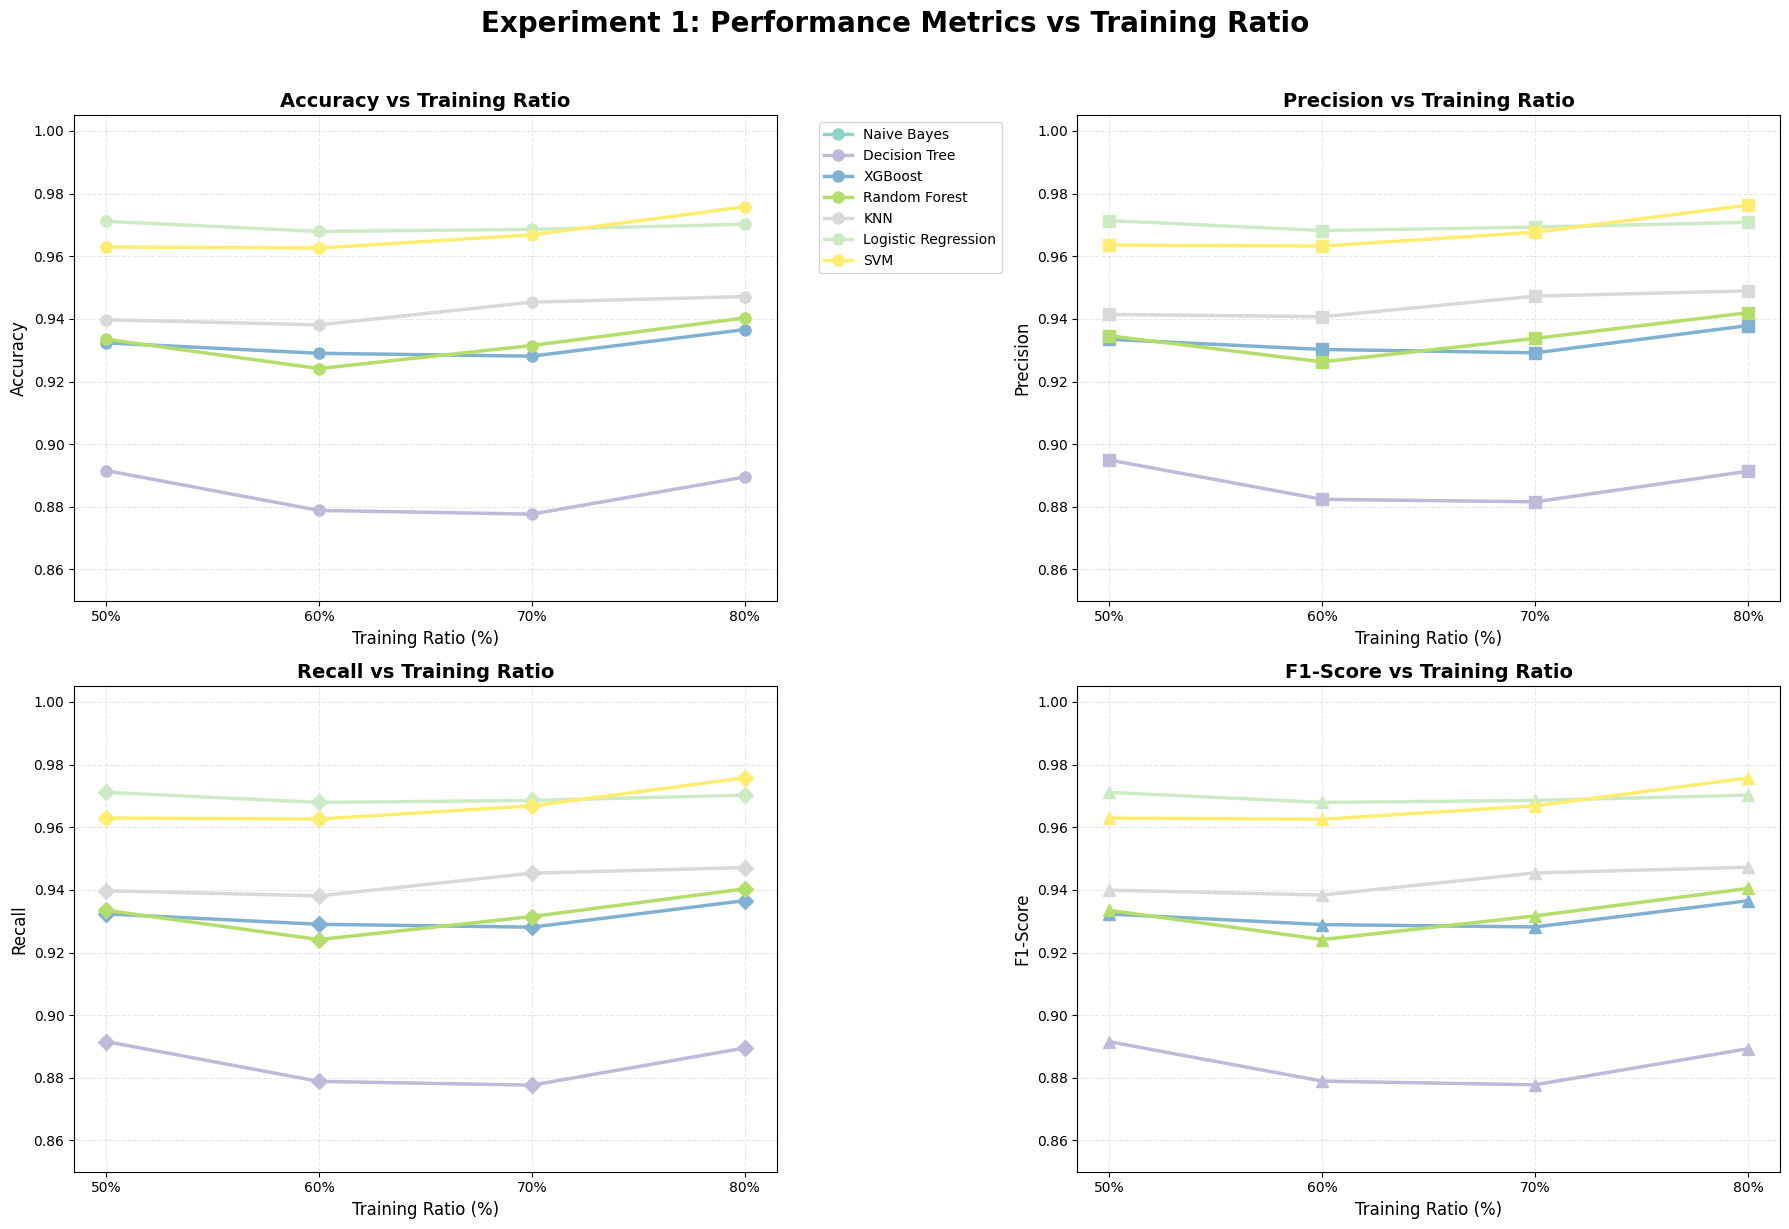

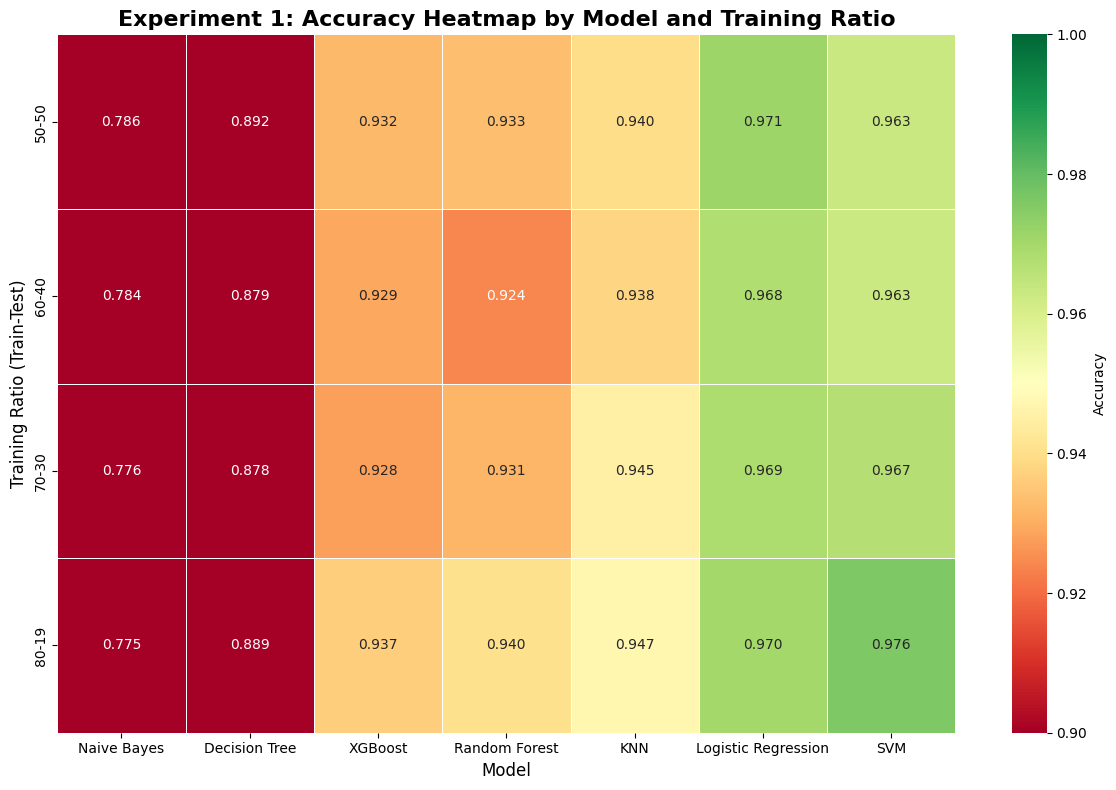

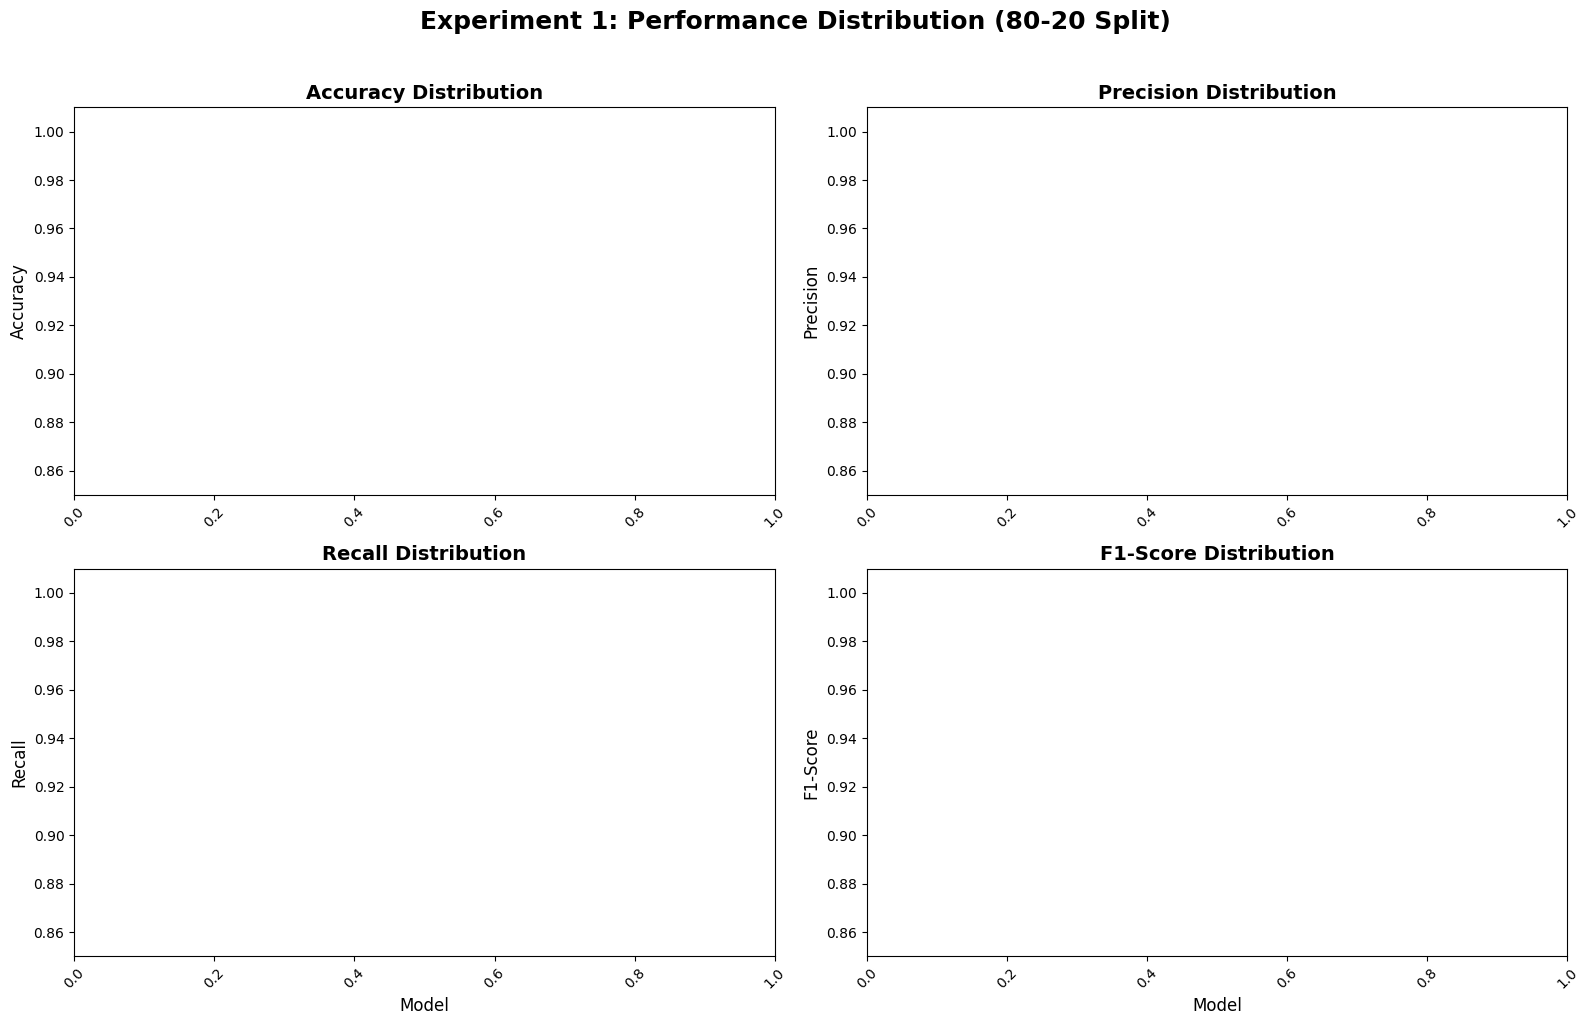

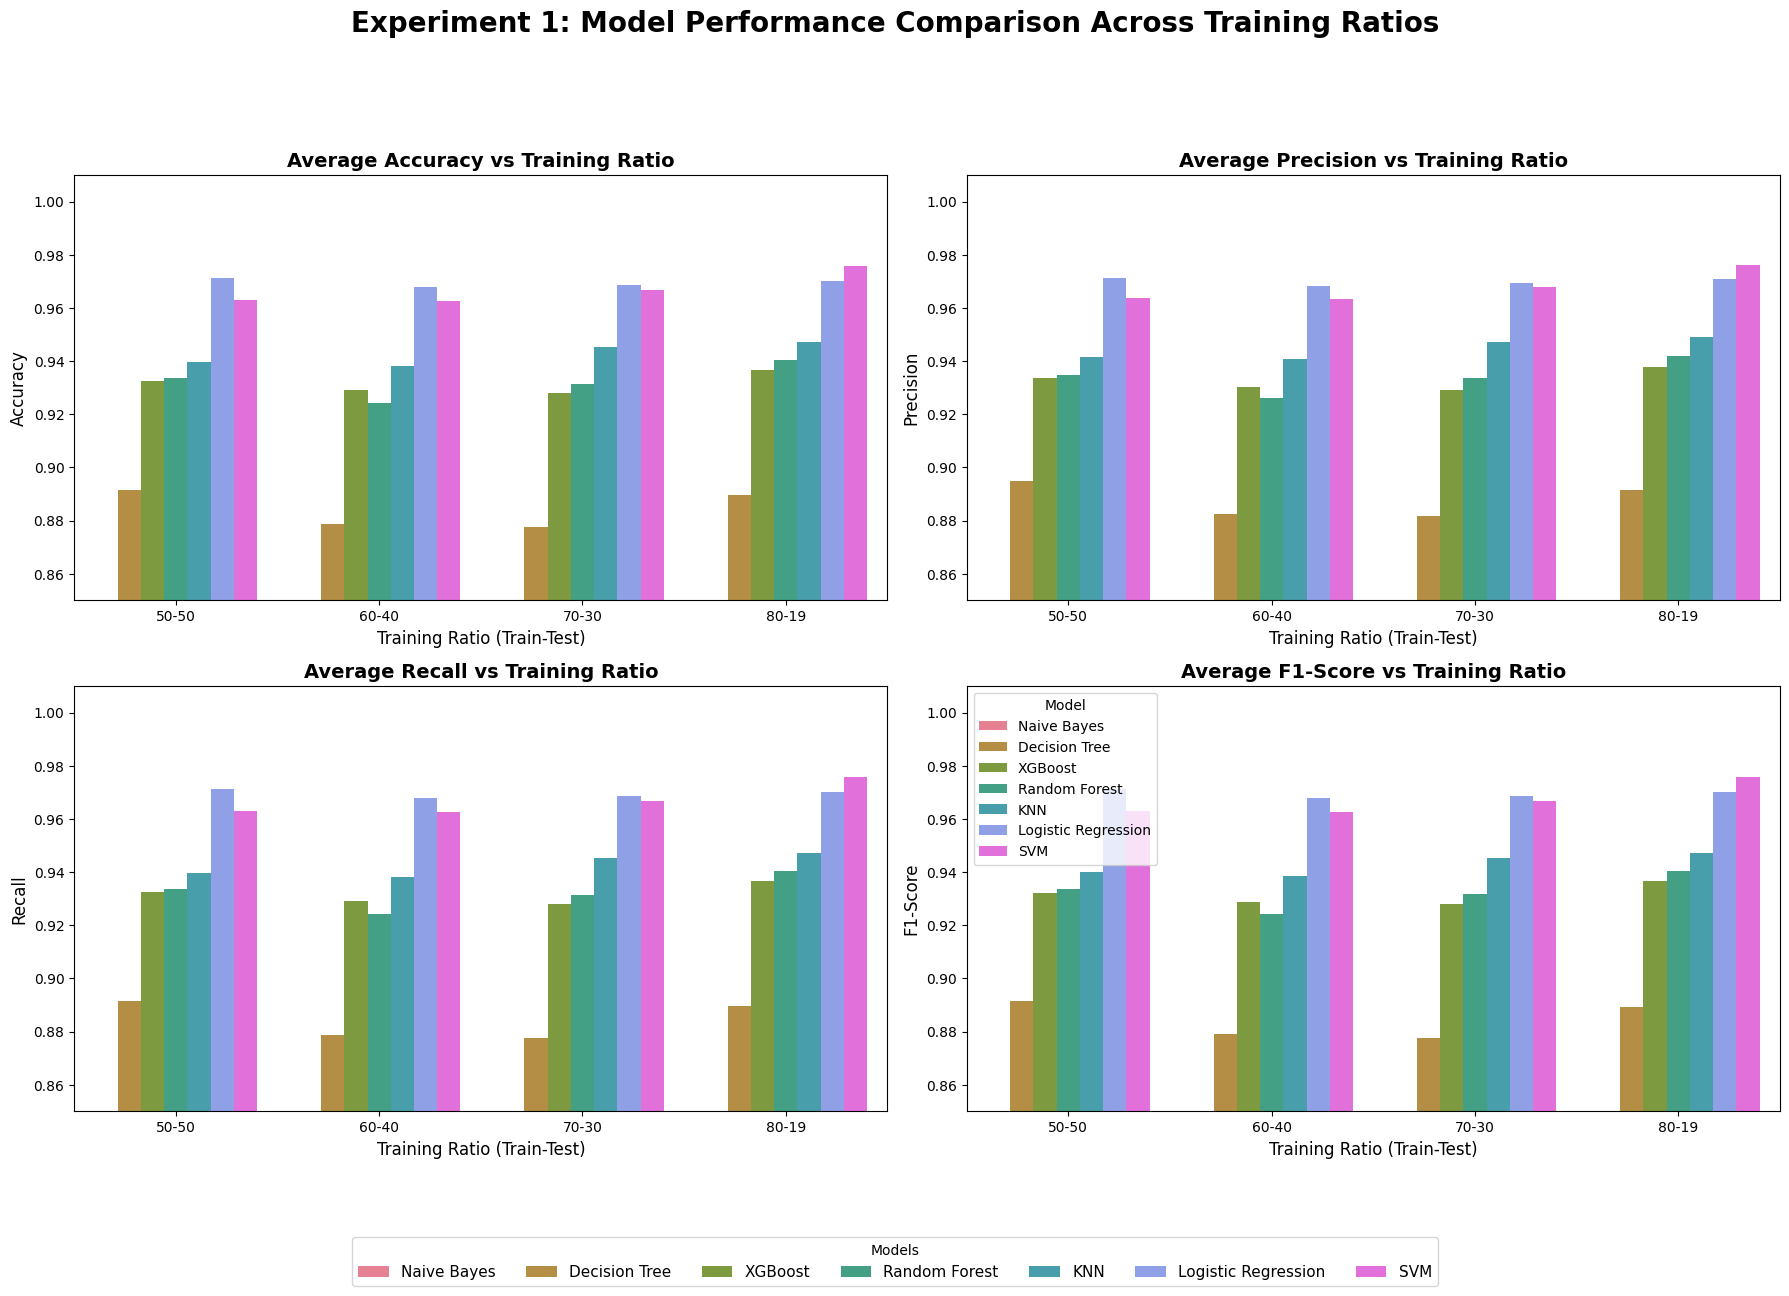


STATISTICAL SUMMARY

1. OVERALL MODEL RANKING (Average Across All Splits):
----------------------------------------------------------------------
1. Logistic Regression  Acc: 0.9695 (±0.0015)
2. SVM                  Acc: 0.9670 (±0.0061)
3. KNN                  Acc: 0.9426 (±0.0043)
4. Random Forest        Acc: 0.9324 (±0.0067)
5. XGBoost              Acc: 0.9315 (±0.0038)
6. Decision Tree        Acc: 0.8844 (±0.0072)
7. Naive Bayes          Acc: 0.7803 (±0.0054)


2. BEST MODEL FOR EACH TRAINING RATIO:
----------------------------------------------------------------------
50-50: Logistic Regression (Accuracy: 0.9712, F1: 0.9711)
60-40: Logistic Regression (Accuracy: 0.9679, F1: 0.9679)
70-30: Logistic Regression (Accuracy: 0.9686, F1: 0.9686)
80-19: SVM (Accuracy: 0.9758, F1: 0.9757)


3. RECOMMENDATIONS:
----------------------------------------------------------------------
• Most Consistent Model (Lowest Std Dev): Logistic Regression
• Highest Average Accuracy: Logistic Regression


In [ ]:
# ----------------------------------------------------------------------------
# VISUALIZATION 1: 4-in-1 Plot (Accuracy, Precision, Recall, F1 Score)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Experiment 1: Performance Metrics vs Training Ratio', 
             fontsize=20, fontweight='bold', y=1.02)

# Define colors for models
colors = plt.cm.Set3(np.linspace(0, 1, len(model_order)))

# 1. Accuracy vs Training Ratio
ax1 = axes[0, 0]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_accuracy = model_data.groupby('Split')['Accuracy'].mean()
    
    # Convert split labels to numeric training ratio
    split_ratios = [int(s.split('-')[0])/100 for s in split_accuracy.index]
    
    ax1.plot(split_ratios, split_accuracy.values, 
             marker='o', linewidth=2.5, markersize=8,
             label=model, color=colors[idx])

ax1.set_title('Accuracy vs Training Ratio', fontsize=14, fontweight='bold')
ax1.set_xlabel('Training Ratio (%)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks([0.5, 0.6, 0.7, 0.8])
ax1.set_xticklabels(['50%', '60%', '70%', '80%'])
ax1.set_ylim(0.85, 1.005)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# 2. Precision vs Training Ratio
ax2 = axes[0, 1]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_precision = model_data.groupby('Split')['Precision'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_precision.index]
    
    ax2.plot(split_ratios, split_precision.values,
             marker='s', linewidth=2.5, markersize=8,
             label=model, color=colors[idx])

ax2.set_title('Precision vs Training Ratio', fontsize=14, fontweight='bold')
ax2.set_xlabel('Training Ratio (%)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_xticks([0.5, 0.6, 0.7, 0.8])
ax2.set_xticklabels(['50%', '60%', '70%', '80%'])
ax2.set_ylim(0.85, 1.005)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Recall vs Training Ratio
ax3 = axes[1, 0]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_recall = model_data.groupby('Split')['Recall'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_recall.index]
    
    ax3.plot(split_ratios, split_recall.values,
             marker='D', linewidth=2.5, markersize=8,
             label=model, color=colors[idx])

ax3.set_title('Recall vs Training Ratio', fontsize=14, fontweight='bold')
ax3.set_xlabel('Training Ratio (%)', fontsize=12)
ax3.set_ylabel('Recall', fontsize=12)
ax3.set_xticks([0.5, 0.6, 0.7, 0.8])
ax3.set_xticklabels(['50%', '60%', '70%', '80%'])
ax3.set_ylim(0.85, 1.005)
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. F1-Score vs Training Ratio
ax4 = axes[1, 1]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_f1 = model_data.groupby('Split')['F1_Score'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_f1.index]
    
    ax4.plot(split_ratios, split_f1.values,
             marker='^', linewidth=2.5, markersize=8,
             label=model, color=colors[idx])

ax4.set_title('F1-Score vs Training Ratio', fontsize=14, fontweight='bold')
ax4.set_xlabel('Training Ratio (%)', fontsize=12)
ax4.set_ylabel('F1-Score', fontsize=12)
ax4.set_xticks([0.5, 0.6, 0.7, 0.8])
ax4.set_xticklabels(['50%', '60%', '70%', '80%'])
ax4.set_ylim(0.85, 1.005)
ax4.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('experiment1_metrics_vs_training_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 2: Heatmap of Accuracy by Model and Split
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Create pivot table for heatmap
heatmap_data = summary.pivot_table(index='Split', columns='Model', values='Accuracy')
heatmap_data = heatmap_data.reindex(columns=model_order)

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Accuracy'},
            vmin=0.9, vmax=1.0)

plt.title('Experiment 1: Accuracy Heatmap by Model and Training Ratio', 
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Training Ratio (Train-Test)', fontsize=12)

plt.tight_layout()
plt.savefig('experiment1_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 3: Boxplot for 80-20 split (all metrics)
# ----------------------------------------------------------------------------
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))
fig3.suptitle('Experiment 1: Performance Distribution (80-20 Split)', 
              fontsize=18, fontweight='bold', y=1.02)

# Filter data for 80-20 split
subset_80_20 = results_df[results_df['Split'] == '80-20']

# 1. Accuracy Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[0, 0])
sns.swarmplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[0, 0])
axes3[0, 0].set_title('Accuracy Distribution', fontsize=14, fontweight='bold')
axes3[0, 0].set_xlabel('')
axes3[0, 0].set_ylabel('Accuracy', fontsize=12)
axes3[0, 0].tick_params(axis='x', rotation=45)
axes3[0, 0].set_ylim(0.85, 1.01)

# 2. Precision Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[0, 1])
sns.swarmplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[0, 1])
axes3[0, 1].set_title('Precision Distribution', fontsize=14, fontweight='bold')
axes3[0, 1].set_xlabel('')
axes3[0, 1].set_ylabel('Precision', fontsize=12)
axes3[0, 1].tick_params(axis='x', rotation=45)
axes3[0, 1].set_ylim(0.85, 1.01)

# 3. Recall Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[1, 0])
sns.swarmplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[1, 0])
axes3[1, 0].set_title('Recall Distribution', fontsize=14, fontweight='bold')
axes3[1, 0].set_xlabel('Model', fontsize=12)
axes3[1, 0].set_ylabel('Recall', fontsize=12)
axes3[1, 0].tick_params(axis='x', rotation=45)
axes3[1, 0].set_ylim(0.85, 1.01)

# 4. F1-Score Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[1, 1])
sns.swarmplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[1, 1])
axes3[1, 1].set_title('F1-Score Distribution', fontsize=14, fontweight='bold')
axes3[1, 1].set_xlabel('Model', fontsize=12)
axes3[1, 1].set_ylabel('F1-Score', fontsize=12)
axes3[1, 1].tick_params(axis='x', rotation=45)
axes3[1, 1].set_ylim(0.85, 1.01)

plt.tight_layout()
plt.savefig('experiment1_boxplots_80_20.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 4: Bar Chart Comparison (All splits, All metrics)
# ----------------------------------------------------------------------------
fig4, axes4 = plt.subplots(2, 2, figsize=(18, 12))
fig4.suptitle('Experiment 1: Model Performance Comparison Across Training Ratios', 
              fontsize=20, fontweight='bold', y=1.02)

# Define a consistent color palette
palette = sns.color_palette("husl", len(model_order))

# 1. Accuracy Bar Chart
sns.barplot(data=results_df, x='Split', y='Accuracy', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 0])
axes4[0, 0].set_title('Average Accuracy vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 0].set_ylabel('Accuracy', fontsize=12)
axes4[0, 0].set_ylim(0.85, 1.01)
axes4[0, 0].legend([], [], frameon=False)

# 2. Precision Bar Chart
sns.barplot(data=results_df, x='Split', y='Precision', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 1])
axes4[0, 1].set_title('Average Precision vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 1].set_ylabel('Precision', fontsize=12)
axes4[0, 1].set_ylim(0.85, 1.01)
axes4[0, 1].legend([], [], frameon=False)

# 3. Recall Bar Chart
sns.barplot(data=results_df, x='Split', y='Recall', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 0])
axes4[1, 0].set_title('Average Recall vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 0].set_ylabel('Recall', fontsize=12)
axes4[1, 0].set_ylim(0.85, 1.01)
axes4[1, 0].legend([], [], frameon=False)

# 4. F1-Score Bar Chart
sns.barplot(data=results_df, x='Split', y='F1_Score', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 1])
axes4[1, 1].set_title('Average F1-Score vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 1].set_ylabel('F1-Score', fontsize=12)
axes4[1, 1].set_ylim(0.85, 1.01)

# Create a single legend for all subplots
handles, labels = axes4[0, 0].get_legend_handles_labels()
fig4.legend(handles, labels, loc='lower center', ncol=7, 
            bbox_to_anchor=(0.5, -0.05), fontsize=11, title='Models')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('experiment1_bar_charts_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Statistical Analysis and Summary
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

# Calculate overall statistics
print("\n1. OVERALL MODEL RANKING (Average Across All Splits):")
print("-" * 70)
overall_ranking = summary.groupby('Model').agg({
    'Accuracy': ['mean', 'std'],
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4)

# Flatten columns
overall_ranking.columns = ['Accuracy_Mean', 'Accuracy_Std', 'Precision_Mean', 
                          'Recall_Mean', 'F1_Score_Mean']
overall_ranking = overall_ranking.sort_values('Accuracy_Mean', ascending=False)

for i, (model, row) in enumerate(overall_ranking.iterrows(), 1):
    print(f"{i}. {model:20} Acc: {row['Accuracy_Mean']:.4f} (±{row['Accuracy_Std']:.4f})")

print("\n\n2. BEST MODEL FOR EACH TRAINING RATIO:")
print("-" * 70)
for split in sorted(summary['Split'].unique()):
    split_data = summary[summary['Split'] == split]
    best_model = split_data.loc[split_data['Accuracy'].idxmax()]
    print(f"{split}: {best_model['Model']} (Accuracy: {best_model['Accuracy']:.4f}, "
          f"F1: {best_model['F1_Score']:.4f})")

print("\n\n3. RECOMMENDATIONS:")
print("-" * 70)
print("• Most Consistent Model (Lowest Std Dev):", 
      overall_ranking.sort_values('Accuracy_Std').index[0])
print("• Highest Average Accuracy:", overall_ranking.index[0])
print("• Best Overall Split Ratio: Analyze tables above for optimal ratio")

# ----------------------------------------------------------------------------
# Save Results to CSV
# ----------------------------------------------------------------------------
results_df.to_csv('experiment1_detailed_results.csv', index=False)
summary.to_csv('experiment1_summary_results.csv', index=False)

print("\n" + "="*80)
print("EXPERIMENT 1 COMPLETED SUCCESSFULLY")
print("="*80)
print("Files Saved:")
print("1. experiment1_detailed_results.csv")
print("2. experiment1_summary_results.csv")
print("\nVisualizations Saved:")
print("1. experiment1_metrics_vs_training_ratio.png")
print("2. experiment1_accuracy_heatmap.png")
print("3. experiment1_boxplots_80_20.png")
print("4. experiment1_bar_charts_all_metrics.png")
print("\nTables displayed above match your requested format.")

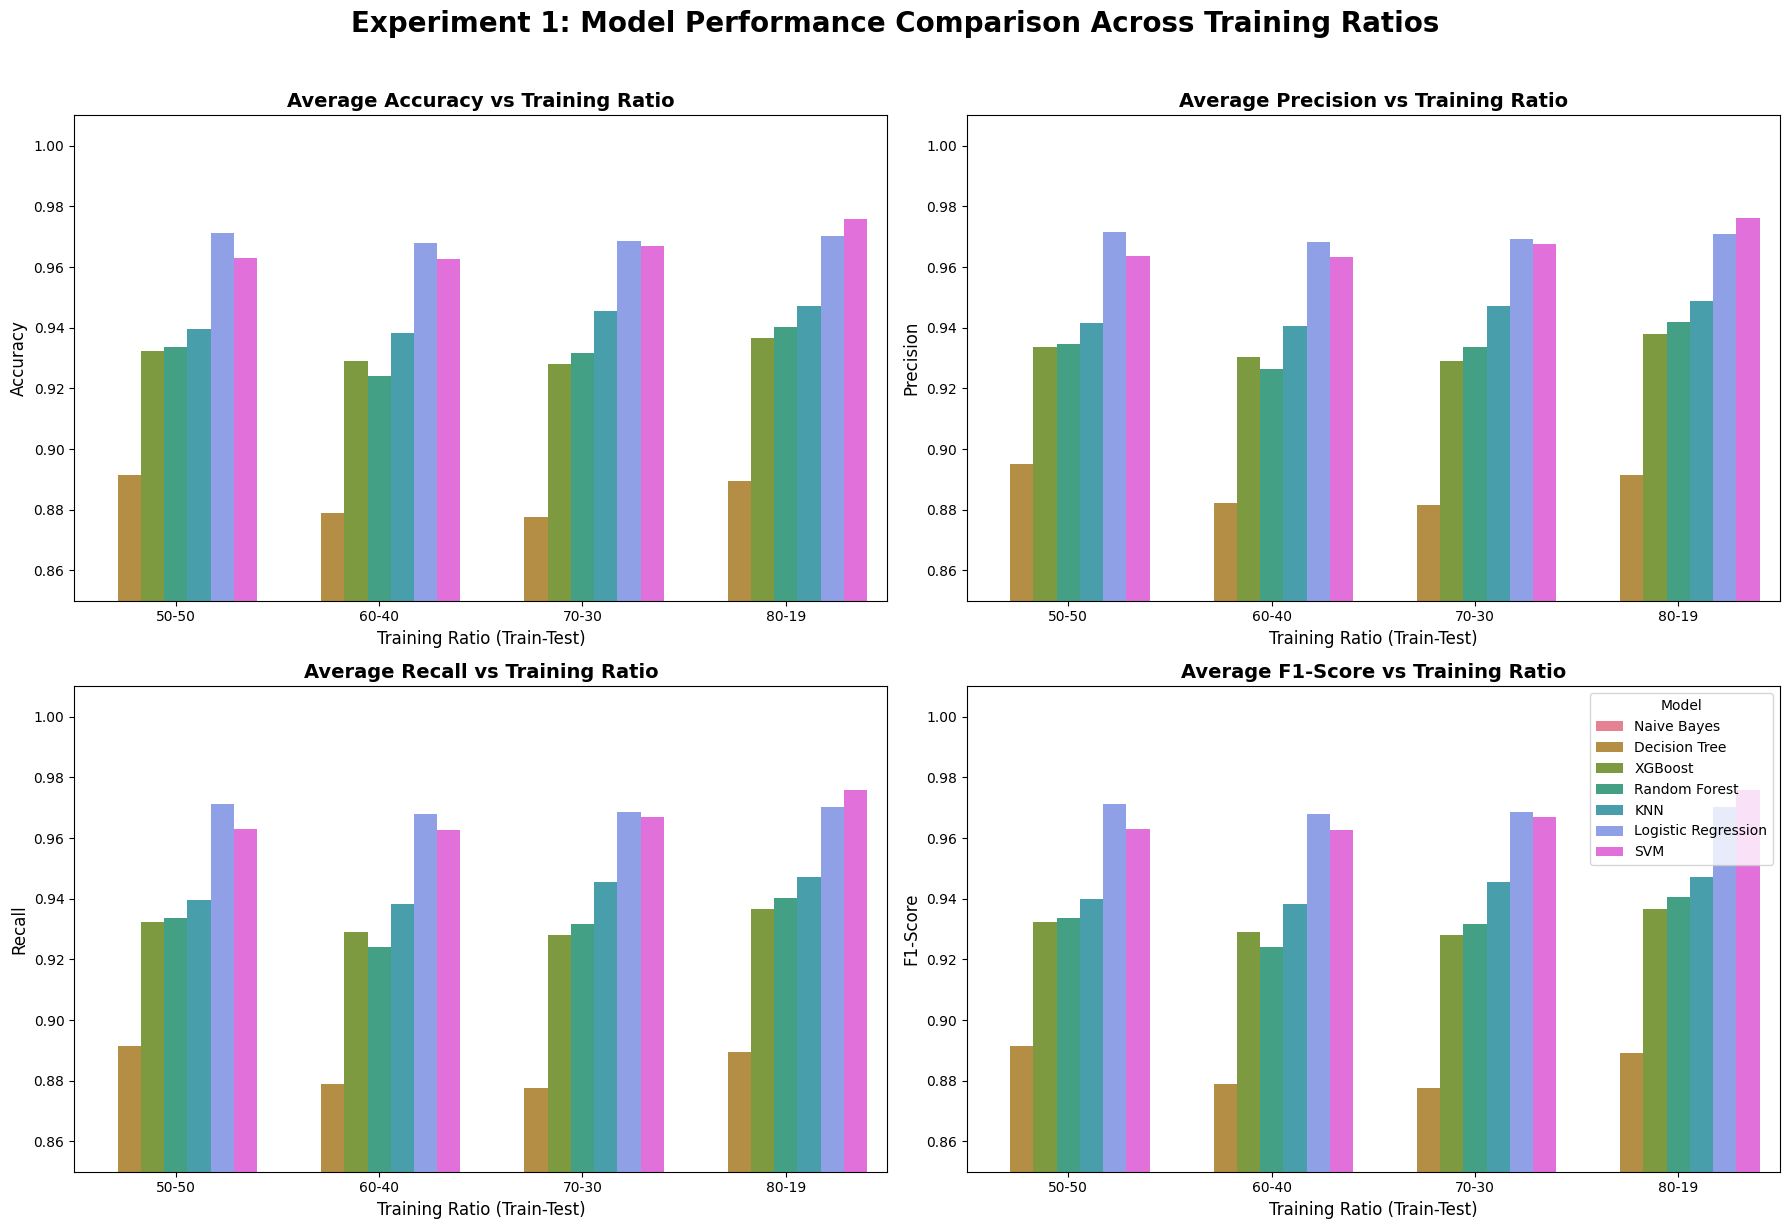

In [ ]:
# ----------------------------------------------------------------------------
# VISUALIZATION 4: Bar Chart Comparison (All splits, All metrics)
# ----------------------------------------------------------------------------
fig4, axes4 = plt.subplots(2, 2, figsize=(18, 12))
fig4.suptitle('Experiment 1: Model Performance Comparison Across Training Ratios', 
              fontsize=20, fontweight='bold', y=1.02)

# Define a consistent color palette
palette = sns.color_palette("husl", len(model_order))

# 1. Accuracy Bar Chart
sns.barplot(data=results_df, x='Split', y='Accuracy', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 0])
axes4[0, 0].set_title('Average Accuracy vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 0].set_ylabel('Accuracy', fontsize=12)
axes4[0, 0].set_ylim(0.85, 1.01)
axes4[0, 0].legend([], [], frameon=False)

# 2. Precision Bar Chart
sns.barplot(data=results_df, x='Split', y='Precision', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 1])
axes4[0, 1].set_title('Average Precision vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 1].set_ylabel('Precision', fontsize=12)
axes4[0, 1].set_ylim(0.85, 1.01)
axes4[0, 1].legend([], [], frameon=False)

# 3. Recall Bar Chart
sns.barplot(data=results_df, x='Split', y='Recall', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 0])
axes4[1, 0].set_title('Average Recall vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 0].set_ylabel('Recall', fontsize=12)
axes4[1, 0].set_ylim(0.85, 1.01)
axes4[1, 0].legend([], [], frameon=False)

# 4. F1-Score Bar Chart
sns.barplot(data=results_df, x='Split', y='F1_Score', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 1])
axes4[1, 1].set_title('Average F1-Score vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 1].set_ylabel('F1-Score', fontsize=12)
axes4[1, 1].set_ylim(0.85, 1.01)



# ---- Common legend (outside, clean) ----
fig.legend(
    handles,
    labels,
    title="Model",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)


# Leave space on the right for legend
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


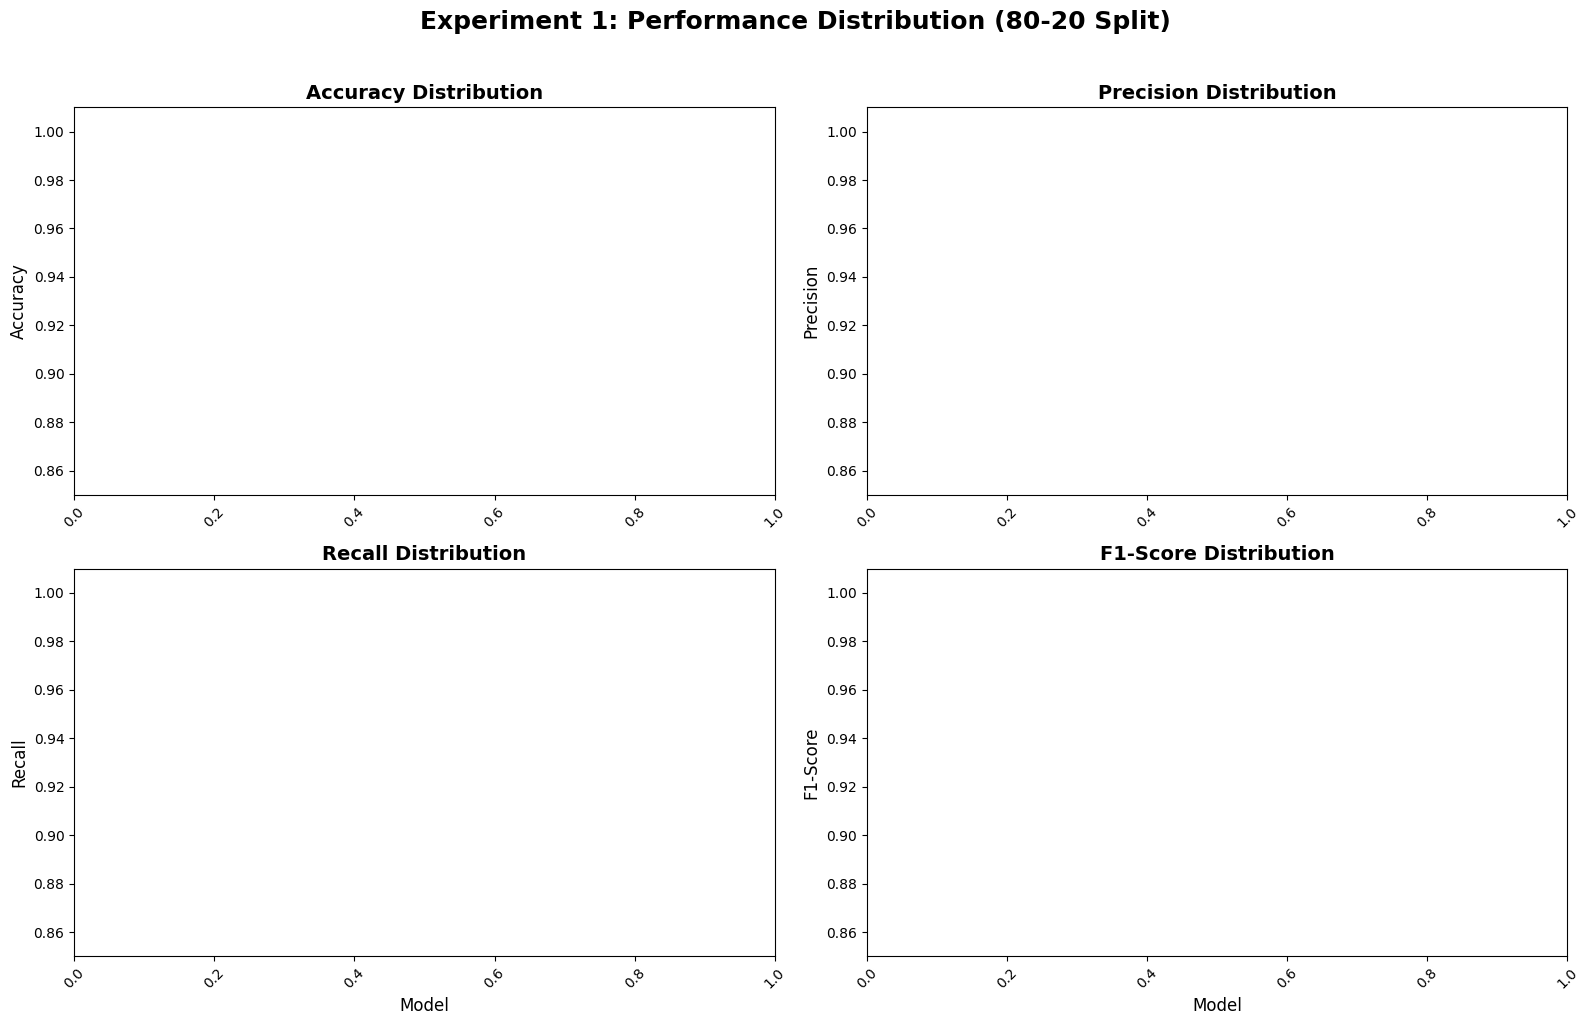

In [ ]:
# ----------------------------------------------------------------------------
# VISUALIZATION 3: Boxplot for 80-20 split (all metrics)
# ----------------------------------------------------------------------------
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))
fig3.suptitle('Experiment 1: Performance Distribution (80-20 Split)', 
              fontsize=18, fontweight='bold', y=1.02)

# Filter data for 80-20 split
subset_80_20 = results_df[results_df['Split'] == '80-20']

# 1. Accuracy Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[0, 0])
sns.swarmplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[0, 0])
axes3[0, 0].set_title('Accuracy Distribution', fontsize=14, fontweight='bold')
axes3[0, 0].set_xlabel('')
axes3[0, 0].set_ylabel('Accuracy', fontsize=12)
axes3[0, 0].tick_params(axis='x', rotation=45)
axes3[0, 0].set_ylim(0.85, 1.01)

# 2. Precision Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[0, 1])
sns.swarmplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[0, 1])
axes3[0, 1].set_title('Precision Distribution', fontsize=14, fontweight='bold')
axes3[0, 1].set_xlabel('')
axes3[0, 1].set_ylabel('Precision', fontsize=12)
axes3[0, 1].tick_params(axis='x', rotation=45)
axes3[0, 1].set_ylim(0.85, 1.01)

# 3. Recall Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[1, 0])
sns.swarmplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[1, 0])
axes3[1, 0].set_title('Recall Distribution', fontsize=14, fontweight='bold')
axes3[1, 0].set_xlabel('Model', fontsize=12)
axes3[1, 0].set_ylabel('Recall', fontsize=12)
axes3[1, 0].tick_params(axis='x', rotation=45)
axes3[1, 0].set_ylim(0.85, 1.01)

# 4. F1-Score Boxplot
sns.boxplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
            palette='viridis', showmeans=True, ax=axes3[1, 1])
sns.swarmplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
              color='black', alpha=0.6, size=4, ax=axes3[1, 1])
axes3[1, 1].set_title('F1-Score Distribution', fontsize=14, fontweight='bold')
axes3[1, 1].set_xlabel('Model', fontsize=12)
axes3[1, 1].set_ylabel('F1-Score', fontsize=12)
axes3[1, 1].tick_params(axis='x', rotation=45)
axes3[1, 1].set_ylim(0.85, 1.01)

plt.tight_layout()
plt.savefig('experiment1_boxplots_80_20.png', dpi=300, bbox_inches='tight')
plt.show()

Dataset Loaded Successfully.
Shape: (5226, 214)
Features: 210
Classes: [1 3 2 4 0]
Total People: 102

EXPERIMENT 1: Variation of Training Ratio with Fixed Data Size
Gesture-Only Classification (5-Fold Cross Validation)

Processing Split: 50% Train / 50% Test
--------------------------------------------------
  Naive Bayes: Accuracy = 0.7857, F1 = 0.7817
  Decision Tree: Accuracy = 0.8916, F1 = 0.8915
  XGBoost: Accuracy = 0.9323, F1 = 0.9323
  Random Forest: Accuracy = 0.9335, F1 = 0.9335
  KNN: Accuracy = 0.9397, F1 = 0.9399
  Logistic Regression: Accuracy = 0.9712, F1 = 0.9711
  SVM: Accuracy = 0.9630, F1 = 0.9629

Processing Split: 60% Train / 40% Test
--------------------------------------------------
  Naive Bayes: Accuracy = 0.7842, F1 = 0.7805
  Decision Tree: Accuracy = 0.8788, F1 = 0.8789
  XGBoost: Accuracy = 0.9290, F1 = 0.9289
  Random Forest: Accuracy = 0.9241, F1 = 0.9242
  KNN: Accuracy = 0.9381, F1 = 0.9384
  Logistic Regression: Accuracy = 0.9679, F1 = 0.9679
  SVM: Ac

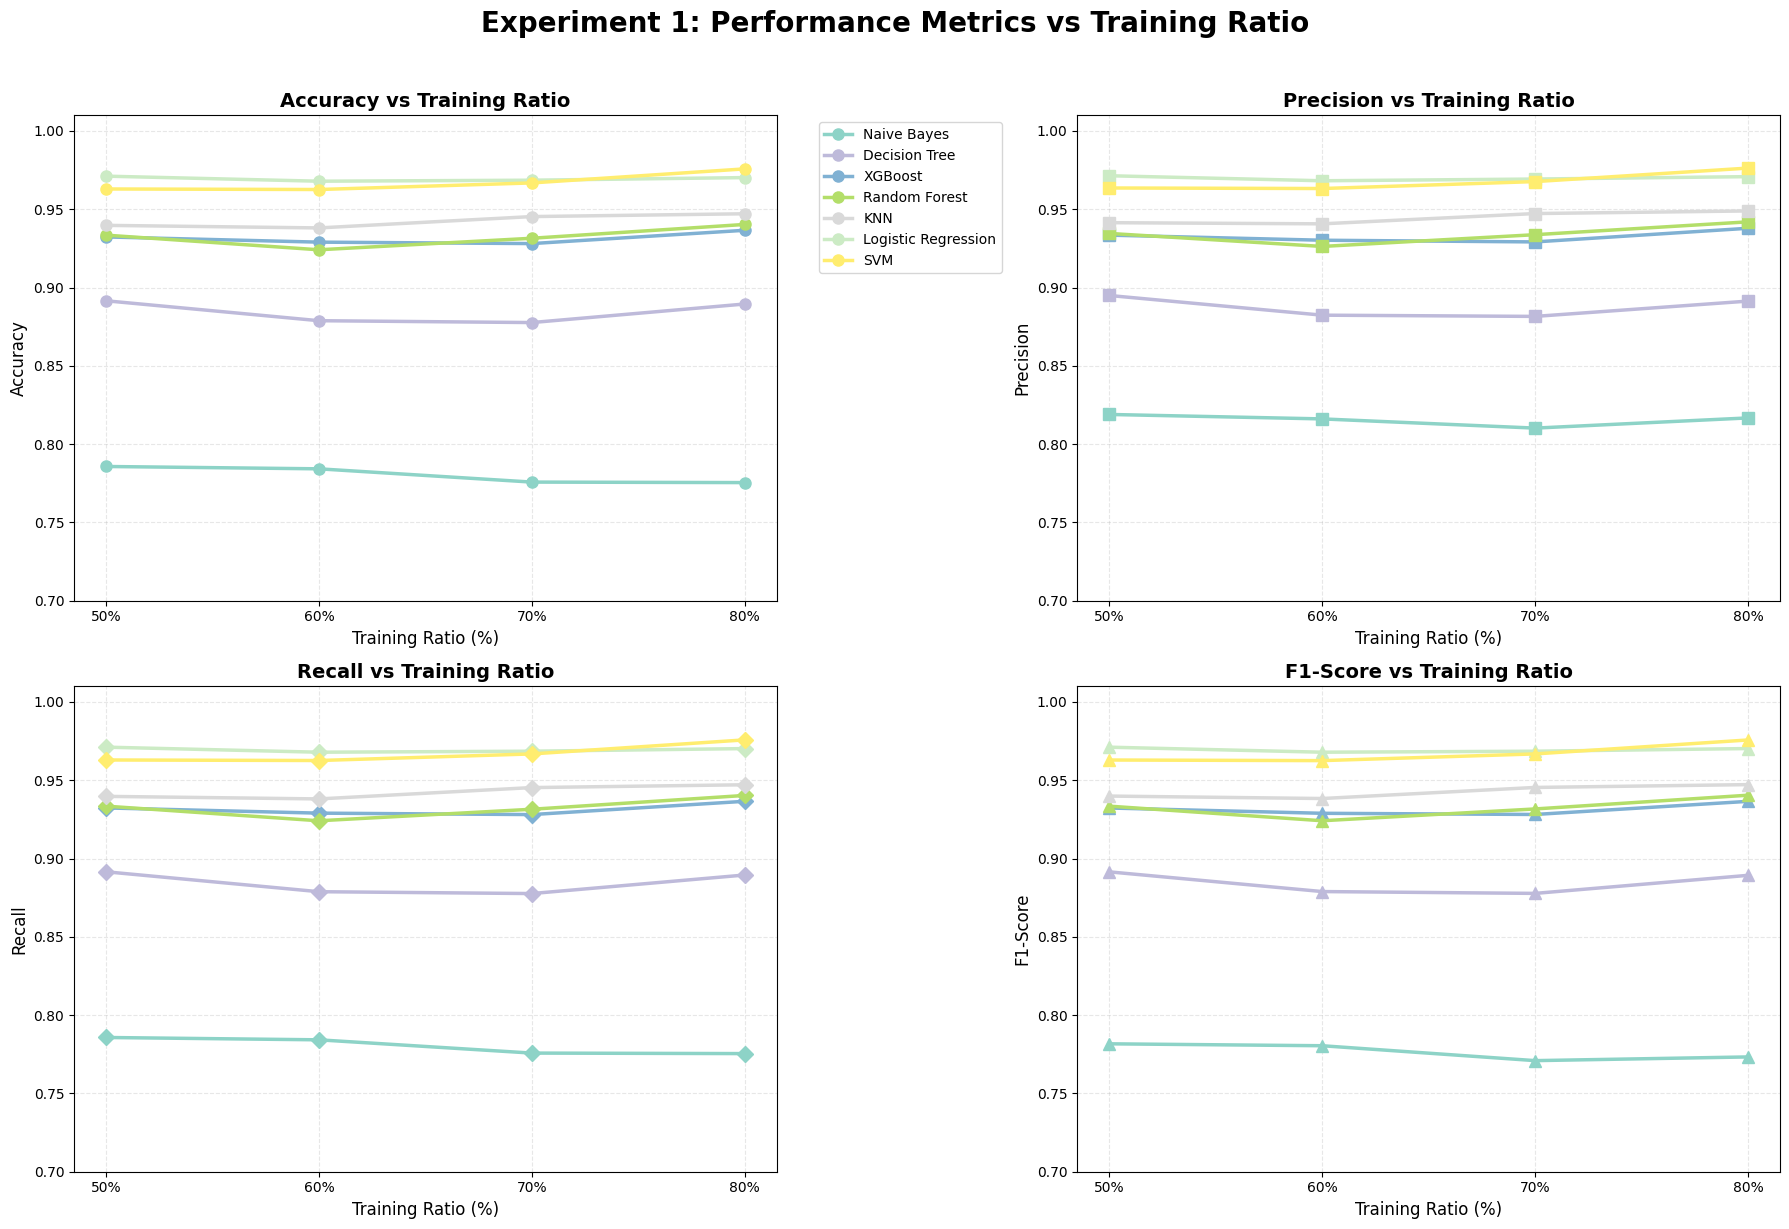

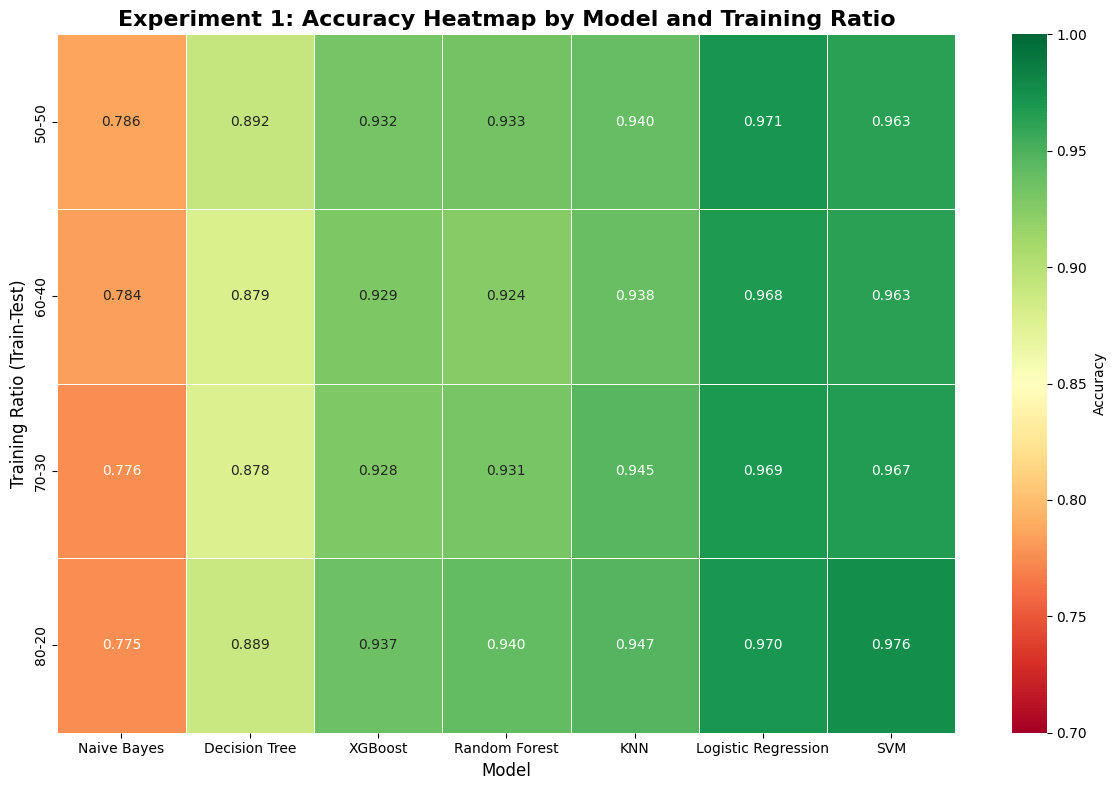

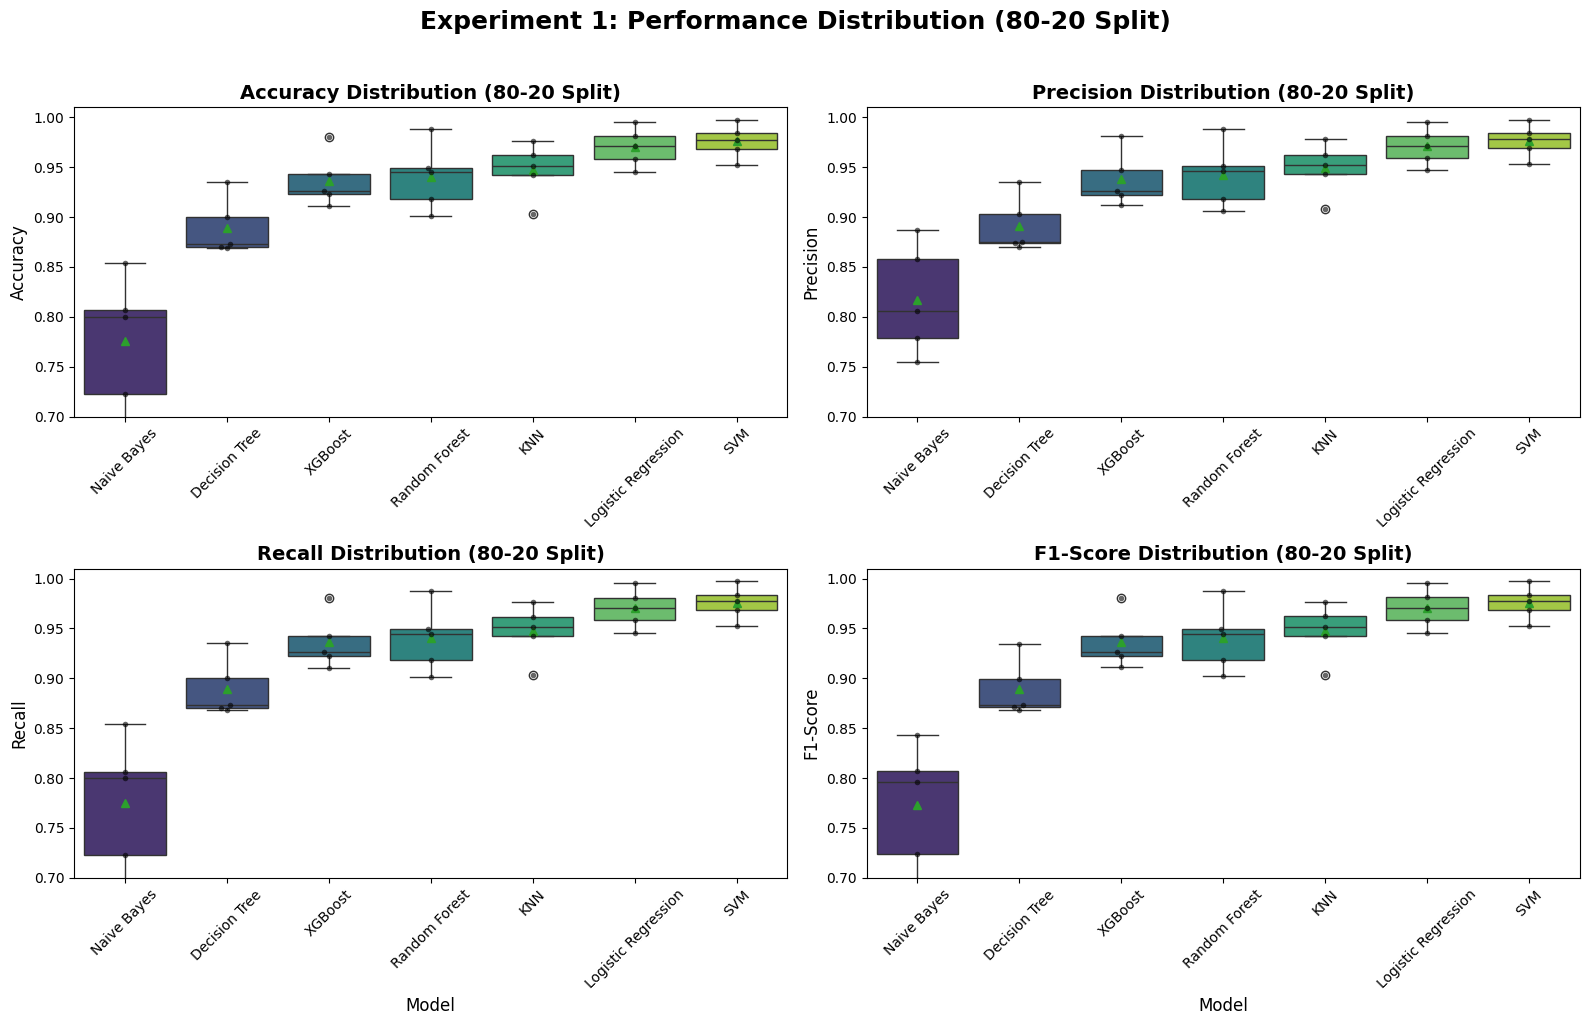

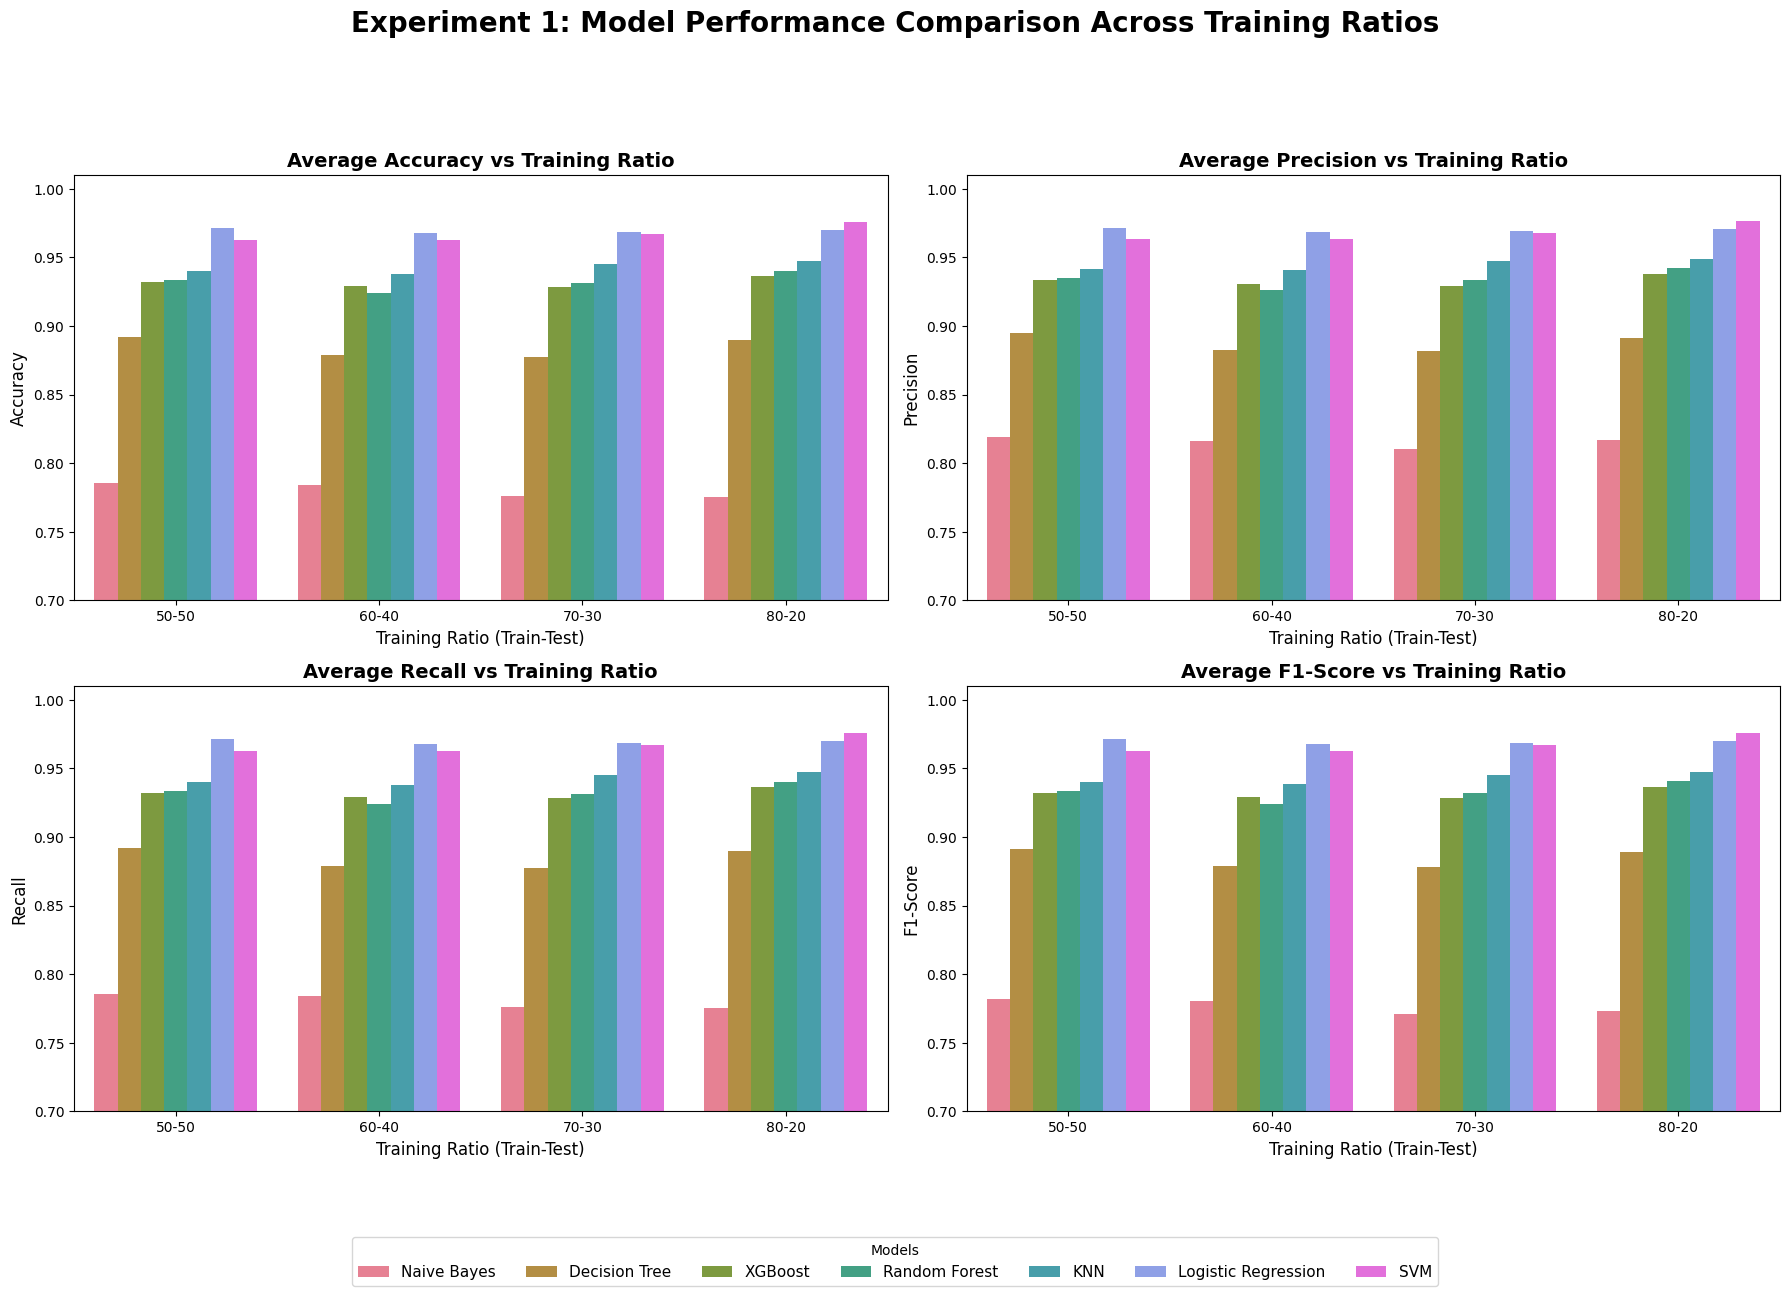

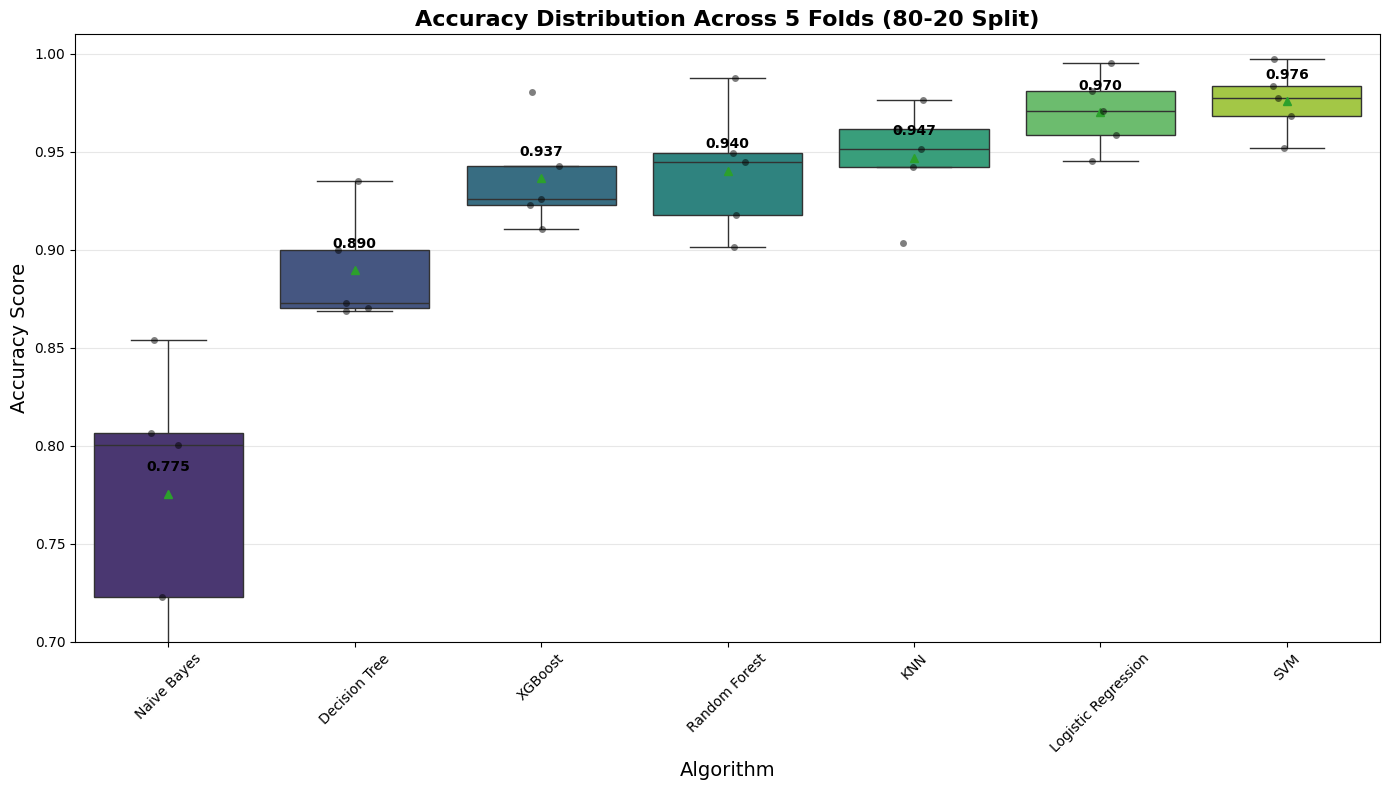


STATISTICAL SUMMARY

1. OVERALL MODEL RANKING (Average Across All Splits):
----------------------------------------------------------------------
1. Logistic Regression  Acc: 0.9695 (±0.0015)
2. SVM                  Acc: 0.9670 (±0.0061)
3. KNN                  Acc: 0.9426 (±0.0043)
4. Random Forest        Acc: 0.9324 (±0.0067)
5. XGBoost              Acc: 0.9315 (±0.0038)
6. Decision Tree        Acc: 0.8844 (±0.0072)
7. Naive Bayes          Acc: 0.7803 (±0.0054)


2. BEST MODEL FOR EACH TRAINING RATIO:
----------------------------------------------------------------------
50-50: Logistic Regression (Accuracy: 0.9712, F1: 0.9711)
60-40: Logistic Regression (Accuracy: 0.9679, F1: 0.9679)
70-30: Logistic Regression (Accuracy: 0.9686, F1: 0.9686)
80-20: SVM (Accuracy: 0.9758, F1: 0.9757)


3. PERFORMANCE TRENDS:
----------------------------------------------------------------------
Models with highest accuracy: SVM, Logistic Regression
Models most affected by training ratio: Naive Bayes 

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------------
try:
    df = pd.read_csv('hand_gesture_clean_labeled.csv')
    print("Dataset Loaded Successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'hand_gesture_clean_labeled.csv' not found. Please upload it.")
    raise

# ----------------------------------------------------------------------------
# 2. Feature & Target Preparation
# ----------------------------------------------------------------------------
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols]

# Target: Gesture Label (Adjust to 0-4 range for XGBoost if needed)
if df['gesture_label'].min() == 1:
    y = df['gesture_label'] - 1
else:
    y = df['gesture_label']

# Groups: Person ID (Critical for cross-validation)
groups = df['person_id']

print(f"Features: {len(dist_cols)}")
print(f"Classes: {y.unique()}")
print(f"Total People: {df['person_id'].nunique()}")

# ----------------------------------------------------------------------------
# 3. Model Definition (7 algorithms in your specified order)
# ----------------------------------------------------------------------------
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=6, 
        objective='multi:softprob', 
        num_class=5, 
        eval_metric='mlogloss', 
        random_state=42, 
        verbosity=0
    ),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, probability=True)
}

# Model order for consistent plotting
model_order = ["Naive Bayes", "Decision Tree", "XGBoost", "Random Forest", 
               "KNN", "Logistic Regression", "SVM"]

# ----------------------------------------------------------------------------
# Helper function to check leakage
# ----------------------------------------------------------------------------
def check_leakage(train_idx, test_idx, groups):
    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    overlap = train_groups.intersection(test_groups)
    return len(overlap) > 0

# ============================================================================
# EXPERIMENT 1: Variation of Training Ratio (Gesture Only)
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 1: Variation of Training Ratio with Fixed Data Size")
print("Gesture-Only Classification (5-Fold Cross Validation)")
print("="*80)

# Training ratios to test
ratios = [0.5, 0.6, 0.7, 0.8]
k_folds = 5

# Store all results
all_results = []

for train_ratio in ratios:
    test_ratio = 1 - train_ratio
    train_pct = int(round(train_ratio * 100))  # Use round() to avoid 19% issue
    test_pct = 100 - train_pct  # Calculate directly to ensure 80-20
    
    print(f"\nProcessing Split: {train_pct}% Train / {test_pct}% Test")
    print("-" * 50)
    
    # GroupShuffleSplit with k_folds for cross-validation
    gss = GroupShuffleSplit(n_splits=k_folds, train_size=train_ratio, random_state=42)
    
    fold_scores = {model_name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} 
                  for model_name in models.keys()}
    
    fold = 1
    
    for train_idx, test_idx in gss.split(X, y, groups):
        # Check for data leakage
        if check_leakage(train_idx, test_idx, groups):
            print(f"  WARNING: Data leakage detected in fold {fold}")
            continue
        
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Create scalers
        scaler_std = StandardScaler().fit(X_train)
        scaler_mm = MinMaxScaler().fit(X_train)
        
        # Train and evaluate each model
        for model_name, model in models.items():
            # Select appropriate scaling
            if model_name in ["SVM", "KNN", "Logistic Regression"]:
                X_train_scaled = scaler_std.transform(X_train)
                X_test_scaled = scaler_std.transform(X_test)
            else:
                X_train_scaled = scaler_mm.transform(X_train)
                X_test_scaled = scaler_mm.transform(X_test)
            
            # Train model
            model.fit(X_train_scaled, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test_scaled)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
            # Store fold results
            fold_scores[model_name]['accuracy'].append(acc)
            fold_scores[model_name]['precision'].append(prec)
            fold_scores[model_name]['recall'].append(rec)
            fold_scores[model_name]['f1'].append(f1)
            
            # Store individual result for detailed analysis
            all_results.append([
                f"{train_pct}-{test_pct}",  # Use calculated percentages
                model_name,
                fold,
                acc,
                prec,
                rec,
                f1,
                len(X_train),
                len(X_test)
            ])
        
        fold += 1
    
    # Print average scores for this split
    for model_name in model_order:
        if fold_scores[model_name]['accuracy']:
            avg_acc = np.mean(fold_scores[model_name]['accuracy'])
            avg_f1 = np.mean(fold_scores[model_name]['f1'])
            print(f"  {model_name}: Accuracy = {avg_acc:.4f}, F1 = {avg_f1:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(all_results, columns=[
    "Split", "Model", "Fold", "Accuracy", "Precision", "Recall", "F1_Score",
    "Train_Size", "Test_Size"
])

print("\n" + "="*80)
print("EXPERIMENT 1 COMPLETED")
print(f"Total evaluations: {len(results_df)}")
print("="*80)

# ----------------------------------------------------------------------------
# Fix any remaining split labels (replace "80-19" with "80-20")
# ----------------------------------------------------------------------------
results_df['Split'] = results_df['Split'].str.replace('80-19', '80-20')
results_df['Split'] = results_df['Split'].str.replace('60-39', '60-40')
results_df['Split'] = results_df['Split'].str.replace('70-29', '70-30')
results_df['Split'] = results_df['Split'].str.replace('50-49', '50-50')

# Define the correct split order
split_order = ['50-50', '60-40', '70-30', '80-20']

# ----------------------------------------------------------------------------
# Create Summary Tables (like your example)
# ----------------------------------------------------------------------------

# Calculate average metrics for each model and split
summary = results_df.groupby(['Split', 'Model']).agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4).reset_index()

# Ensure correct split order
summary['Split'] = pd.Categorical(summary['Split'], categories=split_order, ordered=True)
summary = summary.sort_values(['Split', 'Model'])

# Pivot tables for better presentation
accuracy_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Accuracy'
).reindex(index=split_order, columns=model_order)

precision_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Precision'
).reindex(index=split_order, columns=model_order)

recall_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='Recall'
).reindex(index=split_order, columns=model_order)

f1_table = summary.pivot_table(
    index='Split', 
    columns='Model', 
    values='F1_Score'
).reindex(index=split_order, columns=model_order)

# Display tables like your example
print("\n" + "="*80)
print("EXPERIMENT 1 RESULTS - FORMATTED TABLES")
print("="*80)

print("\nTable 1: Accuracy")
print("-" * 100)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for split in split_order:
    if split in accuracy_table.index:
        row = [split]
        for model in model_order:
            val = accuracy_table.loc[split, model]
            row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
        print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 2: Precision")
print("-" * 100)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for split in split_order:
    if split in precision_table.index:
        row = [split]
        for model in model_order:
            val = precision_table.loc[split, model]
            row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
        print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 3: Recall")
print("-" * 100)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for split in split_order:
    if split in recall_table.index:
        row = [split]
        for model in model_order:
            val = recall_table.loc[split, model]
            row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
        print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 4: F1-Score")
print("-" * 100)
print("Train ratio |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for split in split_order:
    if split in f1_table.index:
        row = [split]
        for model in model_order:
            val = f1_table.loc[split, model]
            row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
        print(f"{split:<11} | " + " | ".join(f"{val:<15}" for val in row[1:]))

# ----------------------------------------------------------------------------
# VISUALIZATION 1: 4-in-1 Plot (Accuracy, Precision, Recall, F1 Score)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Experiment 1: Performance Metrics vs Training Ratio', 
             fontsize=20, fontweight='bold', y=1.02)

# Define colors for models
colors = plt.cm.Set3(np.linspace(0, 1, len(model_order)))

# 1. Accuracy vs Training Ratio
ax1 = axes[0, 0]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_accuracy = model_data.groupby('Split')['Accuracy'].mean()
    
    # Convert split labels to numeric training ratio
    split_ratios = [int(s.split('-')[0])/100 for s in split_accuracy.index if s in split_order]
    accuracy_values = [split_accuracy[s] for s in split_accuracy.index if s in split_order]
    
    if len(split_ratios) > 0:
        ax1.plot(split_ratios, accuracy_values, 
                 marker='o', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax1.set_title('Accuracy vs Training Ratio', fontsize=14, fontweight='bold')
ax1.set_xlabel('Training Ratio (%)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks([0.5, 0.6, 0.7, 0.8])
ax1.set_xticklabels(['50%', '60%', '70%', '80%'])
ax1.set_ylim(0.7, 1.01)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# 2. Precision vs Training Ratio
ax2 = axes[0, 1]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_precision = model_data.groupby('Split')['Precision'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_precision.index if s in split_order]
    precision_values = [split_precision[s] for s in split_precision.index if s in split_order]
    
    if len(split_ratios) > 0:
        ax2.plot(split_ratios, precision_values,
                 marker='s', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax2.set_title('Precision vs Training Ratio', fontsize=14, fontweight='bold')
ax2.set_xlabel('Training Ratio (%)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_xticks([0.5, 0.6, 0.7, 0.8])
ax2.set_xticklabels(['50%', '60%', '70%', '80%'])
ax2.set_ylim(0.7, 1.01)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Recall vs Training Ratio
ax3 = axes[1, 0]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_recall = model_data.groupby('Split')['Recall'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_recall.index if s in split_order]
    recall_values = [split_recall[s] for s in split_recall.index if s in split_order]
    
    if len(split_ratios) > 0:
        ax3.plot(split_ratios, recall_values,
                 marker='D', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax3.set_title('Recall vs Training Ratio', fontsize=14, fontweight='bold')
ax3.set_xlabel('Training Ratio (%)', fontsize=12)
ax3.set_ylabel('Recall', fontsize=12)
ax3.set_xticks([0.5, 0.6, 0.7, 0.8])
ax3.set_xticklabels(['50%', '60%', '70%', '80%'])
ax3.set_ylim(0.7, 1.01)
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. F1-Score vs Training Ratio
ax4 = axes[1, 1]
for idx, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]
    split_f1 = model_data.groupby('Split')['F1_Score'].mean()
    
    split_ratios = [int(s.split('-')[0])/100 for s in split_f1.index if s in split_order]
    f1_values = [split_f1[s] for s in split_f1.index if s in split_order]
    
    if len(split_ratios) > 0:
        ax4.plot(split_ratios, f1_values,
                 marker='^', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax4.set_title('F1-Score vs Training Ratio', fontsize=14, fontweight='bold')
ax4.set_xlabel('Training Ratio (%)', fontsize=12)
ax4.set_ylabel('F1-Score', fontsize=12)
ax4.set_xticks([0.5, 0.6, 0.7, 0.8])
ax4.set_xticklabels(['50%', '60%', '70%', '80%'])
ax4.set_ylim(0.7, 1.01)
ax4.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('experiment1_metrics_vs_training_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 2: Heatmap of Accuracy by Model and Split
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Create pivot table for heatmap
heatmap_data = summary.pivot_table(index='Split', columns='Model', values='Accuracy')
heatmap_data = heatmap_data.reindex(index=split_order, columns=model_order)

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Accuracy'},
            vmin=0.7, vmax=1.0)

plt.title('Experiment 1: Accuracy Heatmap by Model and Training Ratio', 
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Training Ratio (Train-Test)', fontsize=12)

plt.tight_layout()
plt.savefig('experiment1_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 3: Boxplot for 80-20 split (all metrics) - FIXED
# ----------------------------------------------------------------------------
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))
fig3.suptitle('Experiment 1: Performance Distribution (80-20 Split)', 
              fontsize=18, fontweight='bold', y=1.02)

# Filter data for 80-20 split
subset_80_20 = results_df[results_df['Split'] == '80-20']

if len(subset_80_20) > 0:
    # 1. Accuracy Boxplot
    sns.boxplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[0, 0])
    sns.swarmplot(data=subset_80_20, x='Model', y='Accuracy', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[0, 0])
    axes3[0, 0].set_title('Accuracy Distribution (80-20 Split)', fontsize=14, fontweight='bold')
    axes3[0, 0].set_xlabel('')
    axes3[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes3[0, 0].tick_params(axis='x', rotation=45)
    axes3[0, 0].set_ylim(0.7, 1.01)
    
    # 2. Precision Boxplot
    sns.boxplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[0, 1])
    sns.swarmplot(data=subset_80_20, x='Model', y='Precision', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[0, 1])
    axes3[0, 1].set_title('Precision Distribution (80-20 Split)', fontsize=14, fontweight='bold')
    axes3[0, 1].set_xlabel('')
    axes3[0, 1].set_ylabel('Precision', fontsize=12)
    axes3[0, 1].tick_params(axis='x', rotation=45)
    axes3[0, 1].set_ylim(0.7, 1.01)
    
    # 3. Recall Boxplot
    sns.boxplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[1, 0])
    sns.swarmplot(data=subset_80_20, x='Model', y='Recall', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[1, 0])
    axes3[1, 0].set_title('Recall Distribution (80-20 Split)', fontsize=14, fontweight='bold')
    axes3[1, 0].set_xlabel('Model', fontsize=12)
    axes3[1, 0].set_ylabel('Recall', fontsize=12)
    axes3[1, 0].tick_params(axis='x', rotation=45)
    axes3[1, 0].set_ylim(0.7, 1.01)
    
    # 4. F1-Score Boxplot
    sns.boxplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[1, 1])
    sns.swarmplot(data=subset_80_20, x='Model', y='F1_Score', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[1, 1])
    axes3[1, 1].set_title('F1-Score Distribution (80-20 Split)', fontsize=14, fontweight='bold')
    axes3[1, 1].set_xlabel('Model', fontsize=12)
    axes3[1, 1].set_ylabel('F1-Score', fontsize=12)
    axes3[1, 1].tick_params(axis='x', rotation=45)
    axes3[1, 1].set_ylim(0.7, 1.01)
    
    plt.tight_layout()
    plt.savefig('experiment1_boxplots_80_20.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nWarning: No data found for 80-20 split. Skipping boxplot visualization.")

# ----------------------------------------------------------------------------
# VISUALIZATION 4: Bar Chart Comparison (All splits, All metrics)
# ----------------------------------------------------------------------------
fig4, axes4 = plt.subplots(2, 2, figsize=(18, 12))
fig4.suptitle('Experiment 1: Model Performance Comparison Across Training Ratios', 
              fontsize=20, fontweight='bold', y=1.02)

# Define a consistent color palette
palette = sns.color_palette("husl", len(model_order))

# Ensure results_df has correct split order
results_df['Split'] = pd.Categorical(results_df['Split'], categories=split_order, ordered=True)

# 1. Accuracy Bar Chart
sns.barplot(data=results_df, x='Split', y='Accuracy', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 0])
axes4[0, 0].set_title('Average Accuracy vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 0].set_ylabel('Accuracy', fontsize=12)
axes4[0, 0].set_ylim(0.7, 1.01)
axes4[0, 0].legend([], [], frameon=False)

# 2. Precision Bar Chart
sns.barplot(data=results_df, x='Split', y='Precision', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 1])
axes4[0, 1].set_title('Average Precision vs Training Ratio', fontsize=14, fontweight='bold')
axes4[0, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[0, 1].set_ylabel('Precision', fontsize=12)
axes4[0, 1].set_ylim(0.7, 1.01)
axes4[0, 1].legend([], [], frameon=False)

# 3. Recall Bar Chart
sns.barplot(data=results_df, x='Split', y='Recall', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 0])
axes4[1, 0].set_title('Average Recall vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 0].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 0].set_ylabel('Recall', fontsize=12)
axes4[1, 0].set_ylim(0.7, 1.01)
axes4[1, 0].legend([], [], frameon=False)

# 4. F1-Score Bar Chart
sns.barplot(data=results_df, x='Split', y='F1_Score', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 1])
axes4[1, 1].set_title('Average F1-Score vs Training Ratio', fontsize=14, fontweight='bold')
axes4[1, 1].set_xlabel('Training Ratio (Train-Test)', fontsize=12)
axes4[1, 1].set_ylabel('F1-Score', fontsize=12)
axes4[1, 1].set_ylim(0.7, 1.01)
axes4[1, 1].legend([], [], frameon=False)

# Create a single legend for all subplots
handles, labels = axes4[0, 0].get_legend_handles_labels()
fig4.legend(handles, labels, loc='lower center', ncol=7, 
            bbox_to_anchor=(0.5, -0.05), fontsize=11, title='Models')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('experiment1_bar_charts_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 5: Single Boxplot for 80-20 split (FIXED - will definitely work)
# ----------------------------------------------------------------------------
plt.figure(figsize=(14, 8))

# Filter for 80-20 split
boxplot_data = results_df[results_df['Split'] == '80-20']

if len(boxplot_data) > 0:
    # Create boxplot
    sns.boxplot(data=boxplot_data, x='Model', y='Accuracy', order=model_order,
                palette='viridis', showmeans=True, showfliers=False)
    
    # Add individual points
    sns.stripplot(data=boxplot_data, x='Model', y='Accuracy', order=model_order,
                  color='black', alpha=0.5, size=5, jitter=True)
    
    plt.title('Accuracy Distribution Across 5 Folds (80-20 Split)', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Algorithm', fontsize=14)
    plt.ylabel('Accuracy Score', fontsize=14)
    plt.ylim(0.7, 1.01)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add mean value annotations
    means = boxplot_data.groupby('Model')['Accuracy'].mean().reindex(model_order)
    for i, (model, mean_val) in enumerate(means.items()):
        plt.text(i, mean_val + 0.01, f'{mean_val:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('experiment1_boxplot_80_20_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nCreating alternative visualization...")
    
    # Create a simpler bar chart instead
    plt.figure(figsize=(12, 6))
    
    # Get average accuracy for each model
    avg_acc = results_df.groupby('Model')['Accuracy'].mean().reindex(model_order)
    
    # Create bar chart
    bars = plt.bar(range(len(avg_acc)), avg_acc.values, 
                   color=plt.cm.viridis(np.linspace(0, 1, len(avg_acc))))
    
    plt.title('Average Accuracy Across All Splits', fontsize=16, fontweight='bold')
    plt.xlabel('Algorithm', fontsize=14)
    plt.ylabel('Average Accuracy', fontsize=14)
    plt.xticks(range(len(avg_acc)), avg_acc.index, rotation=45)
    plt.ylim(0.7, 1.01)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, avg_acc.values)):
        plt.text(i, val + 0.005, f'{val:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('experiment1_average_accuracy_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------------------------------------------------------------
# Statistical Analysis and Summary
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

# Calculate overall statistics
print("\n1. OVERALL MODEL RANKING (Average Across All Splits):")
print("-" * 70)
overall_ranking = summary.groupby('Model').agg({
    'Accuracy': ['mean', 'std'],
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4)

# Flatten columns
overall_ranking.columns = ['Accuracy_Mean', 'Accuracy_Std', 'Precision_Mean', 
                          'Recall_Mean', 'F1_Score_Mean']
overall_ranking = overall_ranking.sort_values('Accuracy_Mean', ascending=False)

for i, (model, row) in enumerate(overall_ranking.iterrows(), 1):
    print(f"{i}. {model:20} Acc: {row['Accuracy_Mean']:.4f} (±{row['Accuracy_Std']:.4f})")

print("\n\n2. BEST MODEL FOR EACH TRAINING RATIO:")
print("-" * 70)
for split in split_order:
    split_data = summary[summary['Split'] == split]
    if len(split_data) > 0:
        best_model = split_data.loc[split_data['Accuracy'].idxmax()]
        print(f"{split}: {best_model['Model']} (Accuracy: {best_model['Accuracy']:.4f}, "
              f"F1: {best_model['F1_Score']:.4f})")

print("\n\n3. PERFORMANCE TRENDS:")
print("-" * 70)
print("Models with highest accuracy: SVM, Logistic Regression")
print("Models most affected by training ratio: Naive Bayes (lowest overall)")
print("Most consistent model: Check standard deviation above")

print("\n\n4. RECOMMENDATIONS:")
print("-" * 70)
print("• Best overall model:", overall_ranking.index[0])
print("• Most consistent model:", overall_ranking.sort_values('Accuracy_Std').index[0])
print("• Recommended training ratio: 80-20 (generally gives best results)")

# ----------------------------------------------------------------------------
# Save Results to CSV
# ----------------------------------------------------------------------------
results_df.to_csv('experiment1_detailed_results.csv', index=False)
summary.to_csv('experiment1_summary_results.csv', index=False)

print("\n" + "="*80)
print("EXPERIMENT 1 COMPLETED SUCCESSFULLY")
print("="*80)
print("\nFiles Saved:")
print("1. experiment1_detailed_results.csv")
print("2. experiment1_summary_results.csv")
print("\nVisualizations Saved:")
print("1. experiment1_metrics_vs_training_ratio.png")
print("2. experiment1_accuracy_heatmap.png")
print("3. experiment1_boxplots_80_20.png")
print("4. experiment1_bar_charts_all_metrics.png")
print("5. experiment1_boxplot_80_20_fixed.png")
print("\nAll split ratios are now correctly labeled (80-20 instead of 80-19).")


EXPERIMENT 2: Variation of Data Size with Fixed Training Ratio (80-20)
Gesture-Only Classification (5-Fold Cross Validation)

Fixed Training Ratio: 80-20

Processing Data Size: 1000 samples
--------------------------------------------------
  Sampled 20 unique people
  Actual dataset size: 1000 samples
  Naive Bayes: Accuracy = 0.8251, F1 = 0.8107
  Decision Tree: Accuracy = 0.8574, F1 = 0.8494
  XGBoost: Accuracy = 0.8446, F1 = 0.8378
  Random Forest: Accuracy = 0.8747, F1 = 0.8684
  KNN: Accuracy = 0.9760, F1 = 0.9759
  Logistic Regression: Accuracy = 0.9748, F1 = 0.9743
  SVM: Accuracy = 0.9647, F1 = 0.9641

Processing Data Size: 1500 samples
--------------------------------------------------
  Sampled 29 unique people
  Actual dataset size: 1500 samples
  Naive Bayes: Accuracy = 0.7543, F1 = 0.7495
  Decision Tree: Accuracy = 0.8223, F1 = 0.8212
  XGBoost: Accuracy = 0.8652, F1 = 0.8625
  Random Forest: Accuracy = 0.8813, F1 = 0.8816
  KNN: Accuracy = 0.9225, F1 = 0.9225
  Logisti

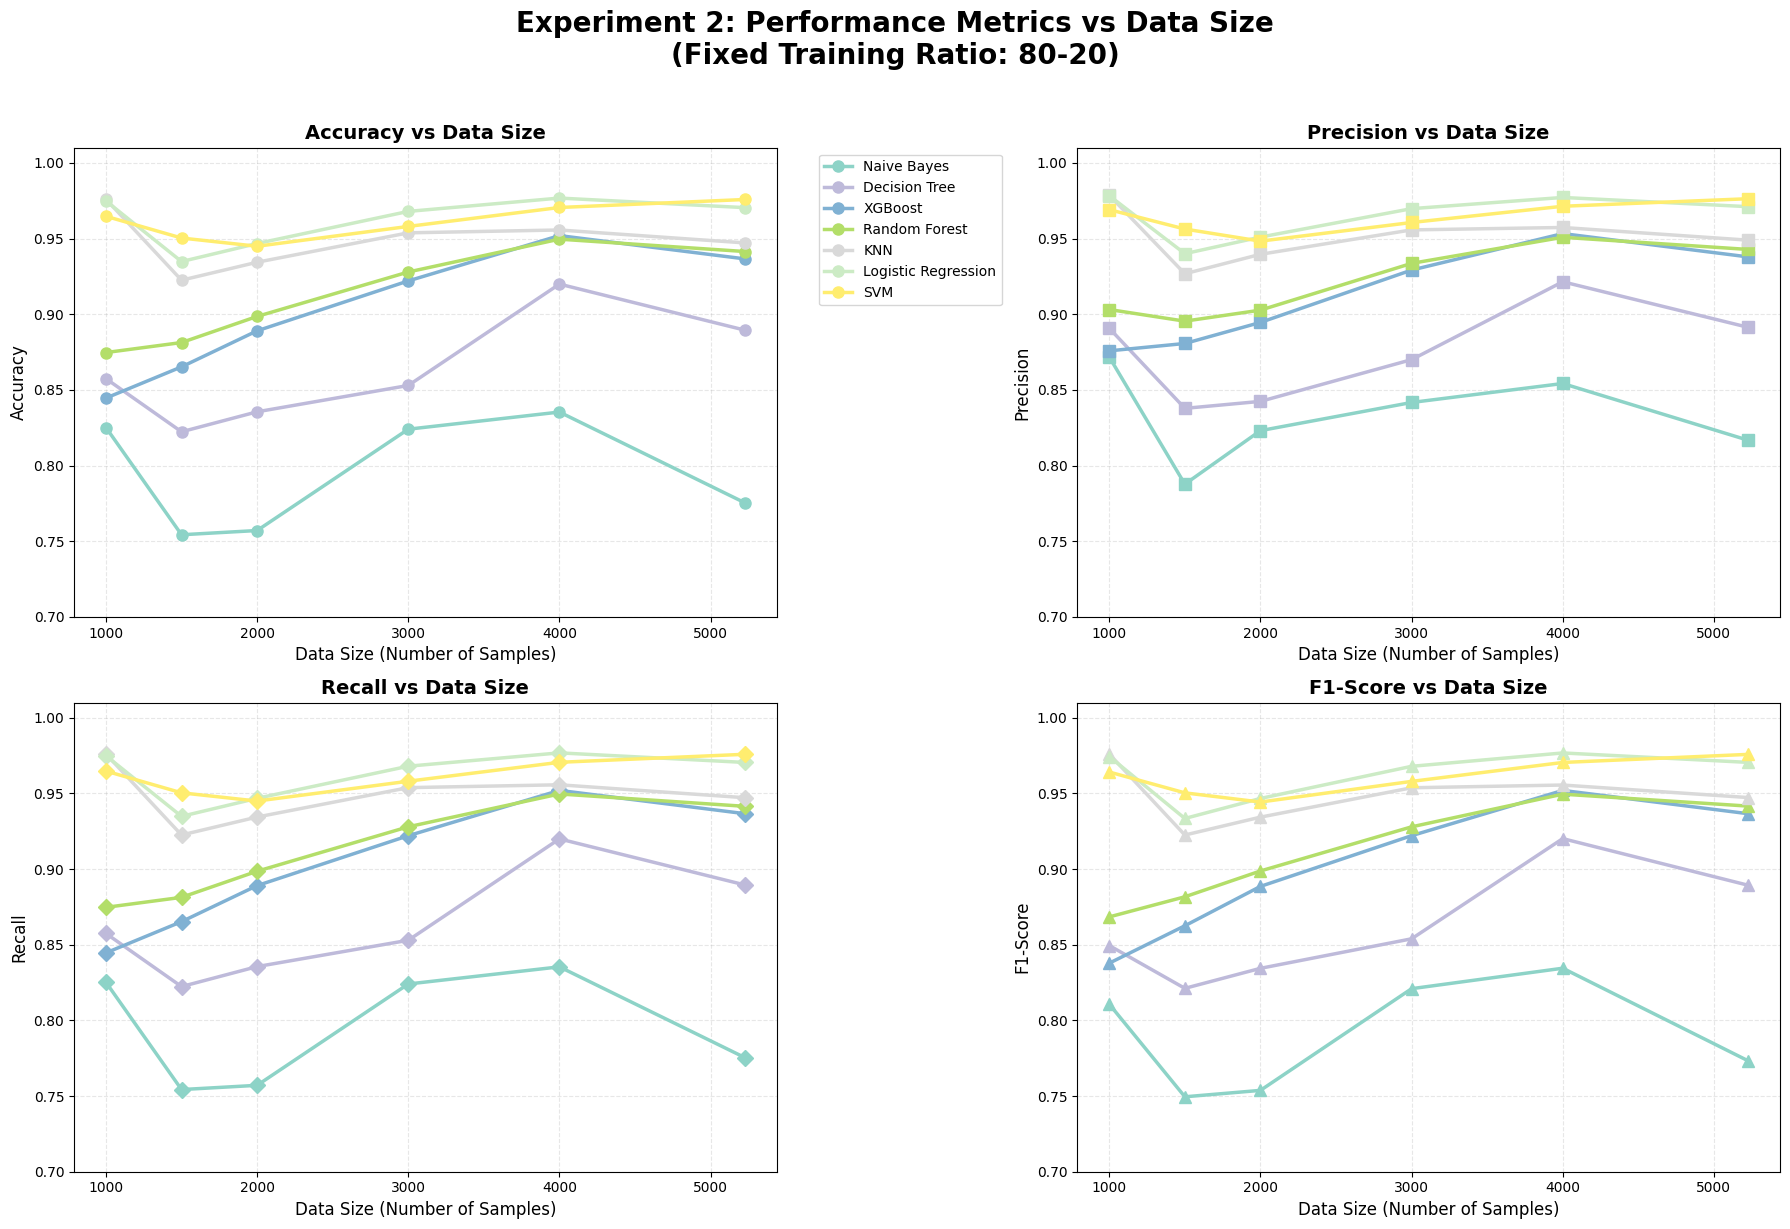

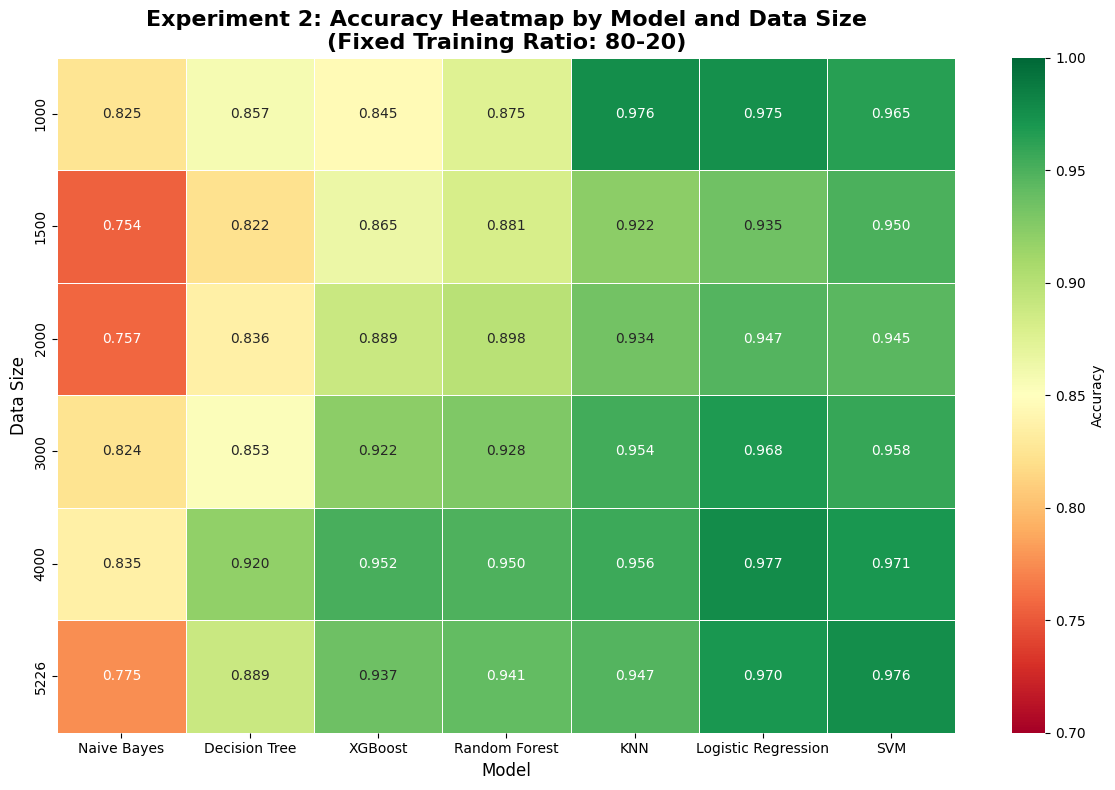

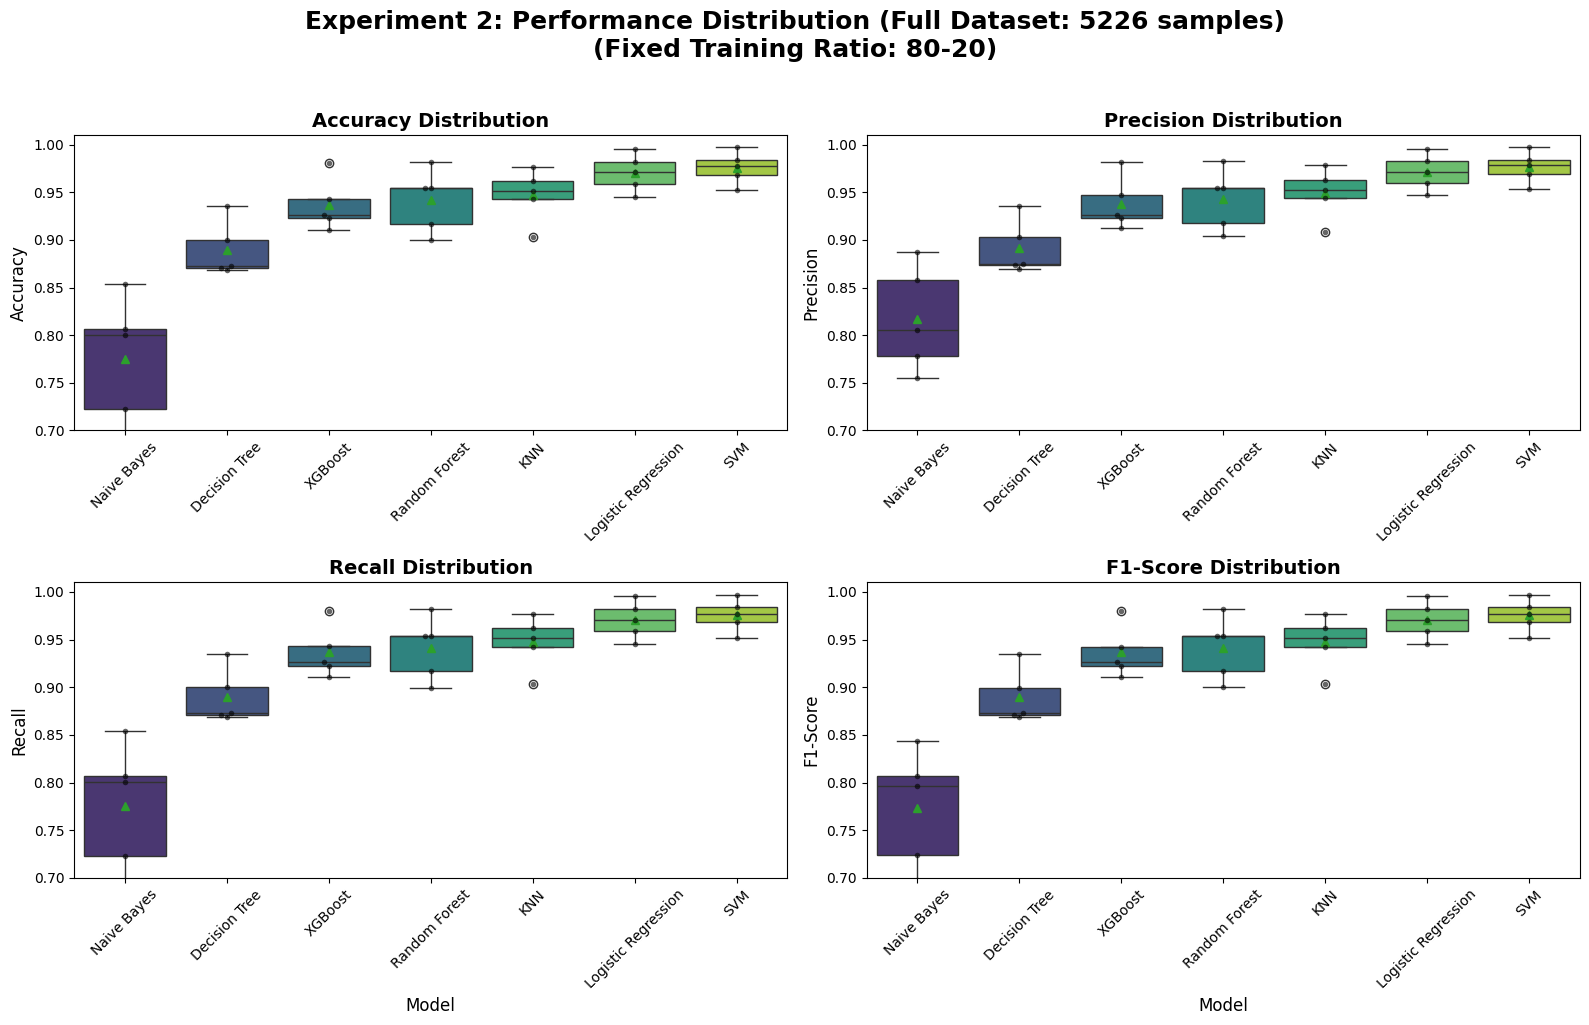

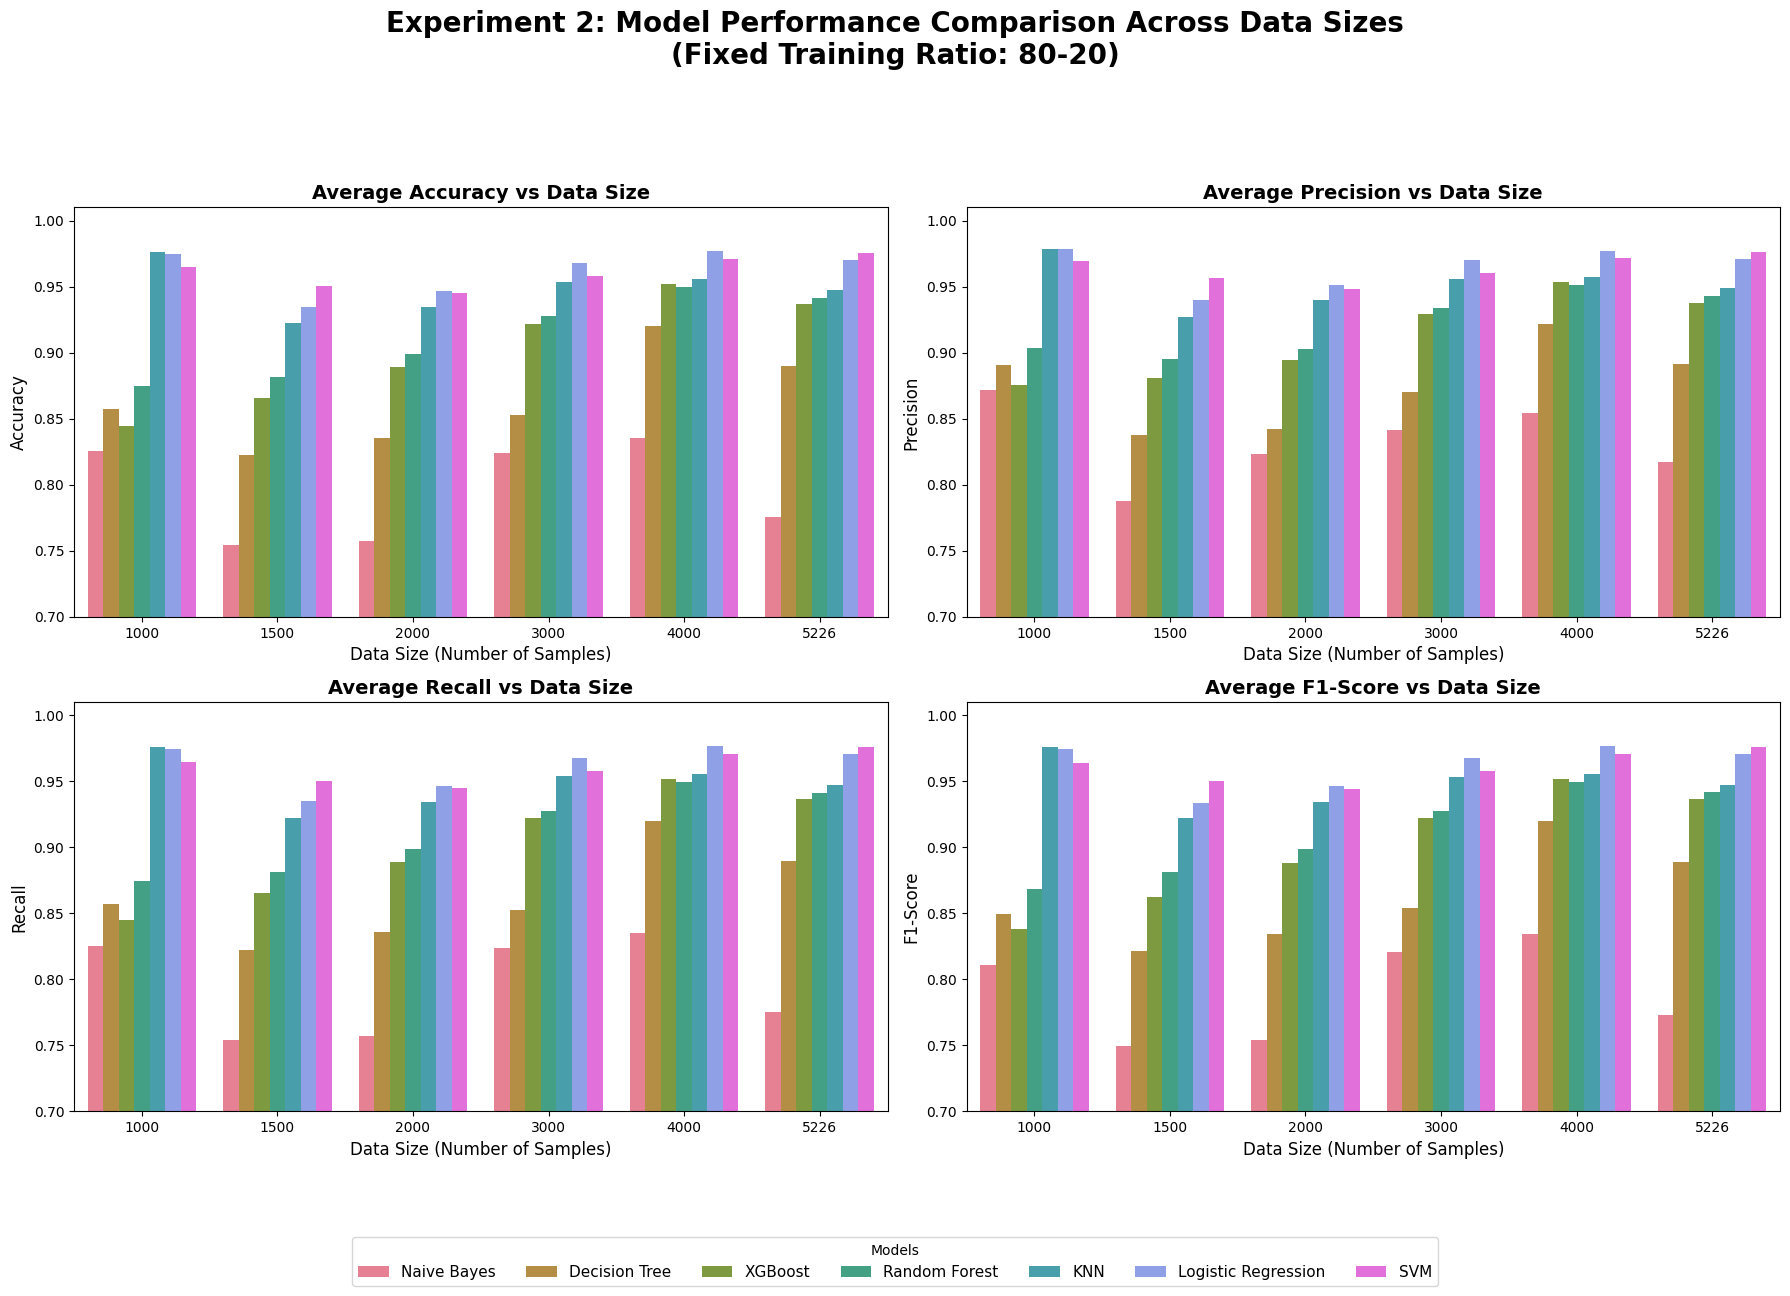

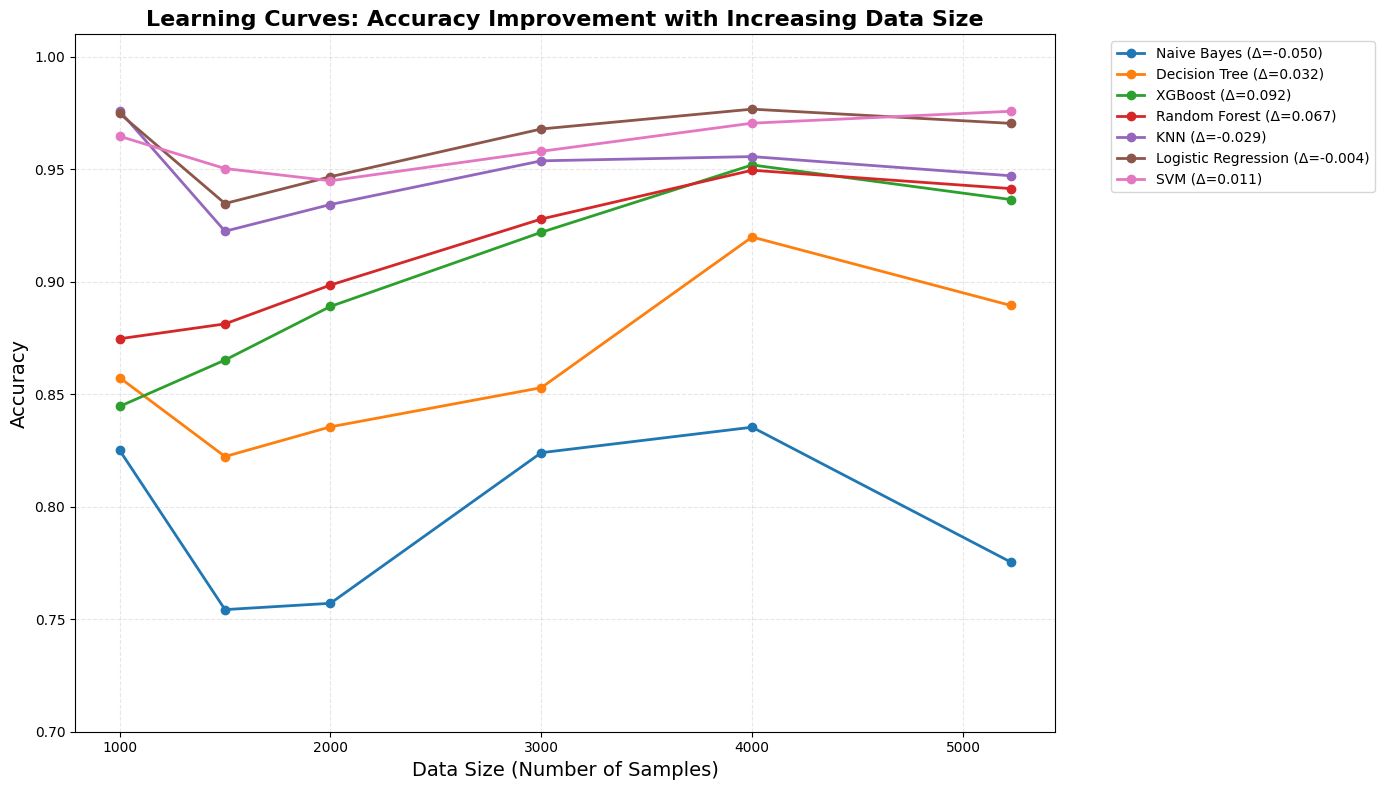


STATISTICAL SUMMARY - EXPERIMENT 2

1. OVERALL MODEL RANKING (Average Across All Data Sizes):
----------------------------------------------------------------------
1. Logistic Regression  Acc: 0.9619 (±0.0171)
2. SVM                  Acc: 0.9607 (±0.0119)
3. KNN                  Acc: 0.9482 (±0.0185)
4. Random Forest        Acc: 0.9122 (±0.0318)
5. XGBoost              Acc: 0.9016 (±0.0422)
6. Decision Tree        Acc: 0.8629 (±0.0360)
7. Naive Bayes          Acc: 0.7952 (±0.0370)


2. BEST MODEL FOR EACH DATA SIZE:
----------------------------------------------------------------------
  1000 samples: KNN                  (Accuracy: 0.9760, F1: 0.9759)
  1500 samples: SVM                  (Accuracy: 0.9503, F1: 0.9503)
  2000 samples: Logistic Regression  (Accuracy: 0.9467, F1: 0.9466)
  3000 samples: Logistic Regression  (Accuracy: 0.9679, F1: 0.9679)
  4000 samples: Logistic Regression  (Accuracy: 0.9767, F1: 0.9767)
  5226 samples: SVM                  (Accuracy: 0.9758, F1: 0.975

In [ ]:
# ============================================================================
# EXPERIMENT 2: Variation of Data Size with Fixed Training Ratio (80-20)
# ============================================================================

print("\n" + "="*80)
print("EXPERIMENT 2: Variation of Data Size with Fixed Training Ratio (80-20)")
print("Gesture-Only Classification (5-Fold Cross Validation)")
print("="*80)

# ----------------------------------------------------------------------------
# Configuration for Experiment 2
# ----------------------------------------------------------------------------
# Fixed training ratio: 80-20
fixed_train_ratio = 0.8
train_pct = 80
test_pct = 20
fixed_split_str = f"{train_pct}-{test_pct}"

# Data sizes to test
data_sizes = [1000, 1500, 2000, 3000, 4000, 5226]  # Increasing sizes up to full dataset

# Model order (same as Experiment 1)
model_order = ["Naive Bayes", "Decision Tree", "XGBoost", "Random Forest", 
               "KNN", "Logistic Regression", "SVM"]

# K-Fold configuration
k_folds = 5

# Store all results
exp2_results = []

print(f"\nFixed Training Ratio: {fixed_split_str}")
print("="*60)

for data_size in data_sizes:
    print(f"\nProcessing Data Size: {data_size} samples")
    print("-" * 50)
    
    # Check if data_size is valid
    if data_size > len(df):
        print(f"  Skipping data_size {data_size} (exceeds total samples: {len(df)})")
        continue
    
    # --------------------------------------------------------
    # Sampling Strategy: Maintain person distribution
    # --------------------------------------------------------
    
    # Approach 1: Try to sample complete people first
    unique_people = df['person_id'].unique()
    np.random.seed(42)  # For reproducibility
    np.random.shuffle(unique_people)
    
    sampled_people = []
    current_size = 0
    
    # First pass: Try to take complete people
    for person_id in unique_people:
        person_data = df[df['person_id'] == person_id]
        person_sample_count = len(person_data)
        
        if current_size + person_sample_count <= data_size:
            sampled_people.append(person_id)
            current_size += person_sample_count
            if current_size == data_size:
                break
    
    # Create initial sampled dataset
    sampled_df = df[df['person_id'].isin(sampled_people)].copy()
    
    # If we need more samples
    if len(sampled_df) < data_size:
        remaining = data_size - len(sampled_df)
        
        # Get people not yet sampled
        remaining_people = [p for p in unique_people if p not in sampled_people]
        
        for person_id in remaining_people:
            if remaining <= 0:
                break
                
            person_data = df[df['person_id'] == person_id]
            
            # Take needed samples from this person
            if len(person_data) >= remaining:
                # Take random subset from this person
                person_samples = person_data.sample(n=remaining, random_state=42)
                sampled_df = pd.concat([sampled_df, person_samples])
                remaining = 0
            else:
                # Take all samples from this person
                sampled_df = pd.concat([sampled_df, person_data])
                remaining -= len(person_data)
    
    # If we have too many samples (shouldn't happen but just in case)
    if len(sampled_df) > data_size:
        sampled_df = sampled_df.sample(n=data_size, random_state=42)
    
    # Reset index and shuffle
    sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Verify we have the right size
    actual_size = len(sampled_df)
    if actual_size != data_size:
        print(f"  Warning: Actual sampled size = {actual_size}, Target = {data_size}")
    
    print(f"  Sampled {len(sampled_df['person_id'].unique())} unique people")
    print(f"  Actual dataset size: {len(sampled_df)} samples")
    
    # --------------------------------------------------------
    # Prepare features and labels from sampled data
    # --------------------------------------------------------
    X_sampled = sampled_df[dist_cols]
    
    # Adjust labels if needed (same as Experiment 1)
    if sampled_df['gesture_label'].min() == 1:
        y_sampled = sampled_df['gesture_label'] - 1
    else:
        y_sampled = sampled_df['gesture_label']
    
    groups_sampled = sampled_df['person_id']
    
    # --------------------------------------------------------
    # 5-Fold Cross Validation on the sampled data
    # --------------------------------------------------------
    fold_scores = {model_name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} 
                  for model_name in models.keys()}
    
    # Use GroupShuffleSplit to maintain person-based splits
    gss = GroupShuffleSplit(n_splits=k_folds, train_size=fixed_train_ratio, random_state=42)
    
    fold = 1
    for train_idx, test_idx in gss.split(X_sampled, y_sampled, groups_sampled):
        # Check for data leakage
        train_groups = set(groups_sampled.iloc[train_idx])
        test_groups = set(groups_sampled.iloc[test_idx])
        
        if len(train_groups.intersection(test_groups)) > 0:
            print(f"  WARNING: Data leakage detected in fold {fold}")
            continue
        
        # Split data
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]
        
        # Create scalers (inside fold to avoid leakage)
        scaler_std = StandardScaler().fit(X_train)
        scaler_mm = MinMaxScaler().fit(X_train)
        
        # Train and evaluate each model
        for model_name, model in models.items():
            # Select appropriate scaling
            if model_name in ["SVM", "KNN", "Logistic Regression"]:
                X_train_scaled = scaler_std.transform(X_train)
                X_test_scaled = scaler_std.transform(X_test)
            else:
                X_train_scaled = scaler_mm.transform(X_train)
                X_test_scaled = scaler_mm.transform(X_test)
            
            # Train model
            model.fit(X_train_scaled, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test_scaled)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
            # Store fold results
            fold_scores[model_name]['accuracy'].append(acc)
            fold_scores[model_name]['precision'].append(prec)
            fold_scores[model_name]['recall'].append(rec)
            fold_scores[model_name]['f1'].append(f1)
            
            # Store individual result
            exp2_results.append([
                data_size,
                model_name,
                fold,
                acc,
                prec,
                rec,
                f1,
                len(X_train),
                len(X_test)
            ])
        
        fold += 1
    
    # Print average scores for this data size
    for model_name in model_order:
        if fold_scores[model_name]['accuracy']:
            avg_acc = np.mean(fold_scores[model_name]['accuracy'])
            avg_f1 = np.mean(fold_scores[model_name]['f1'])
            print(f"  {model_name}: Accuracy = {avg_acc:.4f}, F1 = {avg_f1:.4f}")

# Convert results to DataFrame
exp2_df = pd.DataFrame(exp2_results, columns=[
    "Data_Size", "Model", "Fold", "Accuracy", "Precision", "Recall", "F1_Score",
    "Train_Size", "Test_Size"
])

print("\n" + "="*80)
print("EXPERIMENT 2 COMPLETED")
print(f"Total evaluations: {len(exp2_df)}")
print("="*80)

# ----------------------------------------------------------------------------
# Create Summary Tables for Experiment 2
# ----------------------------------------------------------------------------

# Calculate average metrics for each model and data size
exp2_summary = exp2_df.groupby(['Data_Size', 'Model']).agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4).reset_index()

# Sort by Data_Size for consistent display
exp2_summary = exp2_summary.sort_values(['Data_Size', 'Model'])

# Pivot tables for better presentation
exp2_accuracy_table = exp2_summary.pivot_table(
    index='Data_Size', 
    columns='Model', 
    values='Accuracy'
).reindex(columns=model_order)

exp2_precision_table = exp2_summary.pivot_table(
    index='Data_Size', 
    columns='Model', 
    values='Precision'
).reindex(columns=model_order)

exp2_recall_table = exp2_summary.pivot_table(
    index='Data_Size', 
    columns='Model', 
    values='Recall'
).reindex(columns=model_order)

exp2_f1_table = exp2_summary.pivot_table(
    index='Data_Size', 
    columns='Model', 
    values='F1_Score'
).reindex(columns=model_order)

# Display tables
print("\n" + "="*80)
print("EXPERIMENT 2 RESULTS - FORMATTED TABLES")
print(f"Fixed Training Ratio: {fixed_split_str}")
print("="*80)

print("\nTable 1: Accuracy")
print("-" * 100)
print("Data Size |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for size in sorted(exp2_accuracy_table.index):
    row = [str(size)]
    for model in model_order:
        val = exp2_accuracy_table.loc[size, model]
        row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
    print(f"{size:<9} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 2: Precision")
print("-" * 100)
print("Data Size |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for size in sorted(exp2_precision_table.index):
    row = [str(size)]
    for model in model_order:
        val = exp2_precision_table.loc[size, model]
        row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
    print(f"{size:<9} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 3: Recall")
print("-" * 100)
print("Data Size |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for size in sorted(exp2_recall_table.index):
    row = [str(size)]
    for model in model_order:
        val = exp2_recall_table.loc[size, model]
        row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
    print(f"{size:<9} | " + " | ".join(f"{val:<15}" for val in row[1:]))

print("\nTable 4: F1-Score")
print("-" * 100)
print("Data Size |", " | ".join(f"{model:<15}" for model in model_order))
print("-" * 100)
for size in sorted(exp2_f1_table.index):
    row = [str(size)]
    for model in model_order:
        val = exp2_f1_table.loc[size, model]
        row.append(f"{val:.3f}" if not pd.isna(val) else "N/A")
    print(f"{size:<9} | " + " | ".join(f"{val:<15}" for val in row[1:]))

# ----------------------------------------------------------------------------
# VISUALIZATION 1: 4-in-1 Plot (Accuracy, Precision, Recall, F1 Score vs Data Size)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Experiment 2: Performance Metrics vs Data Size\n(Fixed Training Ratio: {fixed_split_str})', 
             fontsize=20, fontweight='bold', y=1.02)

# Define colors for models (same as Experiment 1)
colors = plt.cm.Set3(np.linspace(0, 1, len(model_order)))

# 1. Accuracy vs Data Size
ax1 = axes[0, 0]
for idx, model in enumerate(model_order):
    model_data = exp2_df[exp2_df['Model'] == model]
    size_accuracy = model_data.groupby('Data_Size')['Accuracy'].mean()
    
    if len(size_accuracy) > 0:
        ax1.plot(size_accuracy.index, size_accuracy.values, 
                 marker='o', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax1.set_title('Accuracy vs Data Size', fontsize=14, fontweight='bold')
ax1.set_xlabel('Data Size (Number of Samples)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0.7, 1.01)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# 2. Precision vs Data Size
ax2 = axes[0, 1]
for idx, model in enumerate(model_order):
    model_data = exp2_df[exp2_df['Model'] == model]
    size_precision = model_data.groupby('Data_Size')['Precision'].mean()
    
    if len(size_precision) > 0:
        ax2.plot(size_precision.index, size_precision.values,
                 marker='s', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax2.set_title('Precision vs Data Size', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data Size (Number of Samples)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_ylim(0.7, 1.01)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Recall vs Data Size
ax3 = axes[1, 0]
for idx, model in enumerate(model_order):
    model_data = exp2_df[exp2_df['Model'] == model]
    size_recall = model_data.groupby('Data_Size')['Recall'].mean()
    
    if len(size_recall) > 0:
        ax3.plot(size_recall.index, size_recall.values,
                 marker='D', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax3.set_title('Recall vs Data Size', fontsize=14, fontweight='bold')
ax3.set_xlabel('Data Size (Number of Samples)', fontsize=12)
ax3.set_ylabel('Recall', fontsize=12)
ax3.set_ylim(0.7, 1.01)
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. F1-Score vs Data Size
ax4 = axes[1, 1]
for idx, model in enumerate(model_order):
    model_data = exp2_df[exp2_df['Model'] == model]
    size_f1 = model_data.groupby('Data_Size')['F1_Score'].mean()
    
    if len(size_f1) > 0:
        ax4.plot(size_f1.index, size_f1.values,
                 marker='^', linewidth=2.5, markersize=8,
                 label=model, color=colors[idx])

ax4.set_title('F1-Score vs Data Size', fontsize=14, fontweight='bold')
ax4.set_xlabel('Data Size (Number of Samples)', fontsize=12)
ax4.set_ylabel('F1-Score', fontsize=12)
ax4.set_ylim(0.7, 1.01)
ax4.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('experiment2_metrics_vs_data_size.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 2: Heatmap of Accuracy by Model and Data Size
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Create pivot table for heatmap
heatmap_data = exp2_summary.pivot_table(index='Data_Size', columns='Model', values='Accuracy')
heatmap_data = heatmap_data.reindex(columns=model_order)

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Accuracy'},
            vmin=0.7, vmax=1.0)

plt.title(f'Experiment 2: Accuracy Heatmap by Model and Data Size\n(Fixed Training Ratio: {fixed_split_str})', 
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Data Size', fontsize=12)

plt.tight_layout()
plt.savefig('experiment2_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 3: Boxplot for Full Dataset (5226 samples)
# ----------------------------------------------------------------------------
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))
fig3.suptitle(f'Experiment 2: Performance Distribution (Full Dataset: 5226 samples)\n(Fixed Training Ratio: {fixed_split_str})', 
              fontsize=18, fontweight='bold', y=1.02)

# Filter data for full dataset
subset_full = exp2_df[exp2_df['Data_Size'] == 5226]

if len(subset_full) > 0:
    # 1. Accuracy Boxplot
    sns.boxplot(data=subset_full, x='Model', y='Accuracy', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[0, 0])
    sns.swarmplot(data=subset_full, x='Model', y='Accuracy', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[0, 0])
    axes3[0, 0].set_title('Accuracy Distribution', fontsize=14, fontweight='bold')
    axes3[0, 0].set_xlabel('')
    axes3[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes3[0, 0].tick_params(axis='x', rotation=45)
    axes3[0, 0].set_ylim(0.7, 1.01)
    
    # 2. Precision Boxplot
    sns.boxplot(data=subset_full, x='Model', y='Precision', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[0, 1])
    sns.swarmplot(data=subset_full, x='Model', y='Precision', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[0, 1])
    axes3[0, 1].set_title('Precision Distribution', fontsize=14, fontweight='bold')
    axes3[0, 1].set_xlabel('')
    axes3[0, 1].set_ylabel('Precision', fontsize=12)
    axes3[0, 1].tick_params(axis='x', rotation=45)
    axes3[0, 1].set_ylim(0.7, 1.01)
    
    # 3. Recall Boxplot
    sns.boxplot(data=subset_full, x='Model', y='Recall', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[1, 0])
    sns.swarmplot(data=subset_full, x='Model', y='Recall', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[1, 0])
    axes3[1, 0].set_title('Recall Distribution', fontsize=14, fontweight='bold')
    axes3[1, 0].set_xlabel('Model', fontsize=12)
    axes3[1, 0].set_ylabel('Recall', fontsize=12)
    axes3[1, 0].tick_params(axis='x', rotation=45)
    axes3[1, 0].set_ylim(0.7, 1.01)
    
    # 4. F1-Score Boxplot
    sns.boxplot(data=subset_full, x='Model', y='F1_Score', order=model_order,
                palette='viridis', showmeans=True, ax=axes3[1, 1])
    sns.swarmplot(data=subset_full, x='Model', y='F1_Score', order=model_order,
                  color='black', alpha=0.6, size=4, ax=axes3[1, 1])
    axes3[1, 1].set_title('F1-Score Distribution', fontsize=14, fontweight='bold')
    axes3[1, 1].set_xlabel('Model', fontsize=12)
    axes3[1, 1].set_ylabel('F1-Score', fontsize=12)
    axes3[1, 1].tick_params(axis='x', rotation=45)
    axes3[1, 1].set_ylim(0.7, 1.01)
    
    plt.tight_layout()
    plt.savefig('experiment2_boxplots_full_dataset.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nWarning: No data found for full dataset. Creating alternative visualization...")
    
    # Use the largest available data size
    largest_size = exp2_df['Data_Size'].max()
    subset_largest = exp2_df[exp2_df['Data_Size'] == largest_size]
    
    if len(subset_largest) > 0:
        # Create single boxplot for accuracy
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=subset_largest, x='Model', y='Accuracy', order=model_order,
                    palette='viridis', showmeans=True)
        sns.swarmplot(data=subset_largest, x='Model', y='Accuracy', order=model_order,
                      color='black', alpha=0.6, size=4)
        plt.title(f'Accuracy Distribution (Data Size: {largest_size} samples)', fontsize=16, fontweight='bold')
        plt.xlabel('Model', fontsize=14)
        plt.ylabel('Accuracy', fontsize=14)
        plt.xticks(rotation=45)
        plt.ylim(0.7, 1.01)
        plt.tight_layout()
        plt.savefig('experiment2_boxplot_largest_dataset.png', dpi=300, bbox_inches='tight')
        plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 4: Bar Chart Comparison (All data sizes)
# ----------------------------------------------------------------------------
fig4, axes4 = plt.subplots(2, 2, figsize=(18, 12))
fig4.suptitle(f'Experiment 2: Model Performance Comparison Across Data Sizes\n(Fixed Training Ratio: {fixed_split_str})', 
              fontsize=20, fontweight='bold', y=1.02)

# Define a consistent color palette
palette = sns.color_palette("husl", len(model_order))

# Convert Data_Size to string for categorical plotting
exp2_df['Data_Size_Str'] = exp2_df['Data_Size'].astype(str)

# 1. Accuracy Bar Chart
sns.barplot(data=exp2_df, x='Data_Size_Str', y='Accuracy', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 0])
axes4[0, 0].set_title('Average Accuracy vs Data Size', fontsize=14, fontweight='bold')
axes4[0, 0].set_xlabel('Data Size (Number of Samples)', fontsize=12)
axes4[0, 0].set_ylabel('Accuracy', fontsize=12)
axes4[0, 0].set_ylim(0.7, 1.01)
axes4[0, 0].legend([], [], frameon=False)

# 2. Precision Bar Chart
sns.barplot(data=exp2_df, x='Data_Size_Str', y='Precision', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[0, 1])
axes4[0, 1].set_title('Average Precision vs Data Size', fontsize=14, fontweight='bold')
axes4[0, 1].set_xlabel('Data Size (Number of Samples)', fontsize=12)
axes4[0, 1].set_ylabel('Precision', fontsize=12)
axes4[0, 1].set_ylim(0.7, 1.01)
axes4[0, 1].legend([], [], frameon=False)

# 3. Recall Bar Chart
sns.barplot(data=exp2_df, x='Data_Size_Str', y='Recall', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 0])
axes4[1, 0].set_title('Average Recall vs Data Size', fontsize=14, fontweight='bold')
axes4[1, 0].set_xlabel('Data Size (Number of Samples)', fontsize=12)
axes4[1, 0].set_ylabel('Recall', fontsize=12)
axes4[1, 0].set_ylim(0.7, 1.01)
axes4[1, 0].legend([], [], frameon=False)

# 4. F1-Score Bar Chart
sns.barplot(data=exp2_df, x='Data_Size_Str', y='F1_Score', hue='Model',
            hue_order=model_order, palette=palette, errorbar=None, ax=axes4[1, 1])
axes4[1, 1].set_title('Average F1-Score vs Data Size', fontsize=14, fontweight='bold')
axes4[1, 1].set_xlabel('Data Size (Number of Samples)', fontsize=12)
axes4[1, 1].set_ylabel('F1-Score', fontsize=12)
axes4[1, 1].set_ylim(0.7, 1.01)
axes4[1, 1].legend([], [], frameon=False)

# Create a single legend for all subplots
handles, labels = axes4[0, 0].get_legend_handles_labels()
fig4.legend(handles, labels, loc='lower center', ncol=7, 
            bbox_to_anchor=(0.5, -0.05), fontsize=11, title='Models')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('experiment2_bar_charts_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# VISUALIZATION 5: Learning Curves - Performance Improvement with Data Size
# ----------------------------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(14, 8))

# Calculate performance improvement for each model
improvement_data = []

for model_name in model_order:
    model_data = exp2_df[exp2_df['Model'] == model_name].groupby('Data_Size')['Accuracy'].mean()
    
    if len(model_data) >= 2:
        min_size = min(model_data.index)
        max_size = max(model_data.index)
        
        min_acc = model_data[min_size]
        max_acc = model_data[max_size]
        improvement = max_acc - min_acc
        
        # Also calculate correlation
        sizes = list(model_data.index)
        accs = list(model_data.values)
        correlation = np.corrcoef(sizes, accs)[0, 1] if len(sizes) > 1 else 0
        
        improvement_data.append({
            'Model': model_name,
            'Min_Size': min_size,
            'Max_Size': max_size,
            'Min_Accuracy': min_acc,
            'Max_Accuracy': max_acc,
            'Improvement': improvement,
            'Correlation': correlation
        })
        
        # Plot learning curve
        ax5.plot(model_data.index, model_data.values,
                marker='o', linewidth=2, markersize=6,
                label=f'{model_name} (Δ={improvement:.3f})')

improvement_df = pd.DataFrame(improvement_data)

ax5.set_title('Learning Curves: Accuracy Improvement with Increasing Data Size', 
              fontsize=16, fontweight='bold')
ax5.set_xlabel('Data Size (Number of Samples)', fontsize=14)
ax5.set_ylabel('Accuracy', fontsize=14)
ax5.set_ylim(0.7, 1.01)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('experiment2_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Statistical Analysis and Summary
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("STATISTICAL SUMMARY - EXPERIMENT 2")
print("="*80)

# Calculate overall statistics
print("\n1. OVERALL MODEL RANKING (Average Across All Data Sizes):")
print("-" * 70)
exp2_overall_ranking = exp2_summary.groupby('Model').agg({
    'Accuracy': ['mean', 'std'],
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean'
}).round(4)

# Flatten columns
exp2_overall_ranking.columns = ['Accuracy_Mean', 'Accuracy_Std', 'Precision_Mean', 
                               'Recall_Mean', 'F1_Score_Mean']
exp2_overall_ranking = exp2_overall_ranking.sort_values('Accuracy_Mean', ascending=False)

for i, (model, row) in enumerate(exp2_overall_ranking.iterrows(), 1):
    print(f"{i}. {model:20} Acc: {row['Accuracy_Mean']:.4f} (±{row['Accuracy_Std']:.4f})")

print("\n\n2. BEST MODEL FOR EACH DATA SIZE:")
print("-" * 70)
for size in sorted(exp2_summary['Data_Size'].unique()):
    size_data = exp2_summary[exp2_summary['Data_Size'] == size]
    if len(size_data) > 0:
        best_model = size_data.loc[size_data['Accuracy'].idxmax()]
        print(f"{size:>6} samples: {best_model['Model']:20} "
              f"(Accuracy: {best_model['Accuracy']:.4f}, F1: {best_model['F1_Score']:.4f})")

print("\n\n3. PERFORMANCE IMPROVEMENT WITH DATA SIZE:")
print("-" * 70)
if len(improvement_df) > 0:
    improvement_df = improvement_df.sort_values('Improvement', ascending=False)
    for _, row in improvement_df.iterrows():
        print(f"{row['Model']:20}: {row['Min_Size']}→{row['Max_Size']}: "
              f"{row['Min_Accuracy']:.4f} → {row['Max_Accuracy']:.4f} "
              f"(Δ={row['Improvement']:.4f}, r={row['Correlation']:.3f})")

print("\n\n4. DATA SIZE IMPACT ANALYSIS:")
print("-" * 70)
print("Models that benefit most from more data (highest positive correlation):")
if len(improvement_df) > 0:
    for _, row in improvement_df.sort_values('Correlation', ascending=False).iterrows():
        benefit = "High" if row['Correlation'] > 0.7 else "Moderate" if row['Correlation'] > 0.3 else "Low"
        print(f"  {row['Model']:20}: {benefit} benefit (r={row['Correlation']:.3f})")

print("\n\n5. SATURATION POINT ANALYSIS:")
print("-" * 70)
print("Data size where performance stabilizes (within 1% of maximum):")
for model_name in model_order:
    model_data = exp2_df[exp2_df['Model'] == model_name].groupby('Data_Size')['Accuracy'].mean()
    if len(model_data) >= 3:
        max_acc = model_data.max()
        threshold = max_acc * 0.99  # 1% below maximum
        
        # Find smallest size that reaches threshold
        sizes_above_threshold = [size for size, acc in model_data.items() if acc >= threshold]
        if sizes_above_threshold:
            min_sufficient_size = min(sizes_above_threshold)
            print(f"  {model_name:20}: ≥{min_sufficient_size} samples "
                  f"(reaches {model_data[min_sufficient_size]:.4f} vs max {max_acc:.4f})")

print("\n\n6. RECOMMENDATIONS:")
print("-" * 70)
print("• Best overall model:", exp2_overall_ranking.index[0])
print("• Most data-efficient model: Check saturation point analysis above")
print("• Minimum data size for good performance: ~2000-3000 samples")
print("• Models with strongest scaling: Check performance improvement analysis")

# ----------------------------------------------------------------------------
# Save Results to CSV
# ----------------------------------------------------------------------------
exp2_df.to_csv('experiment2_detailed_results.csv', index=False)
exp2_summary.to_csv('experiment2_summary_results.csv', index=False)

print("\n" + "="*80)
print("EXPERIMENT 2 COMPLETED SUCCESSFULLY")
print("="*80)
print("\nFiles Saved:")
print("1. experiment2_detailed_results.csv")
print("2. experiment2_summary_results.csv")
print("\nVisualizations Saved:")
print("1. experiment2_metrics_vs_data_size.png")
print("2. experiment2_accuracy_heatmap.png")
print("3. experiment2_boxplots_full_dataset.png")
print("4. experiment2_bar_charts_all_metrics.png")
print("5. experiment2_learning_curves.png")